<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет,  Арсений! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Модель предсказания отмены бронирования номеров в отеле

## Общая информация

- Компания UrbanStay - представитель гостиничного бизнеса.
- Цель компании —  максимизация прибыли сети отелей.
- Ключевой фактор, который снижает прибыль компании и мешает ее нормальному функционированию - отмена броней номеров незадолго до заселения. 

## Проблема

Клиенты отменяют брони номеров в последний момент.

Последствия для бизнеса:
- упущенная выручка
- нарушение нормального функционирование бизнеса (персонал то перегружен, то проставивает; продукты портятся и тд.)
- потеря доверия со стороны партнеров (штрафы и отказы в сотрудничестве)

## Текущее решение 

Овербукинг
- такой подход основан на интуиции, что ненадежно и неконтроллируемо. Есть репутационные риски при просчете

## Бизнес-требования

Необходимо разработать инструмент, который позволит:

1. Заранее выявлять рискованные бронирования, то есть те, что с высокой вероятностью будут отменены.
2. Принимать превентивные меры — например, предлагать неуверенным клиентам гибкие условия или альтернативные даты, чтобы сохранить бронь.
3. Снизить долю отмен в последний момент с 30% до 10% за ближайшие шесть месяцев

## Ожидаемый эффект 

Если цель будут достигнута, то это улучшит положение UrbanStay:

- Повысит загрузку отелей до 80% и более.
- Сократит потери выручки от простоя номеров.
- Наладит планирование работы персонала и закупок.
- Укрепит доверие партнёров.
- Высвободит ресурсы для развития сервиса.

---
## Цель работы
- создание модели прогнозирования отмены брони на основе данных о клиенте

## Задачи
- разработать модель предсказания вероятности отмены брони
- расчитать экономический эффект от ее внедрения


## ML постановка

**Вид задачи:**
- обучение с учителем
- подтип: классификация

**Целевая переменная:**
- booking_status - статус бронирования: `отказ_брони`, `нет_отказа`

**Данные:**

- hotel_bookings - история бронирования
- hotel_reviews - отзывы проживающих. Текстовые данные, из которых можно выделить дополнительные признаки для модели (feature engineering)

**Метрики**
1. Оценка качества предсказаний моделей: 
    - **accuracy, precision, recall, F1‑мера**
2. Оценка экономического эффекта от внедрения: 

    - Прирост дохода благодаря модели: **IR** (англ. Incremental Revenue)

    - Динамика доли отмен бронирования: $\text{Динамика отмен} = \frac{\text{Доля отмен до} - \text{Доля отмен после}}{\text{Доля отмен до}} \times 100\%$

    - Динамика загрузки отелей: $\text{Динамика загрузки} = \frac{\text{Загрузка отеля до} - \text{Загрузка отеля после}}{\text{Загрузка отеля до}} \times 100\%$


**Используемые технологии**
- Python - загрузка данных, ИАД, формирования итогового датасета, предобработка
- Библиотеки CatBoost, LightGBM, XGBoost для обучения ML моделей градиентного бустинга
- Техника N-gams для векторизации текстовых данных и формирования новых признаков для обучения модели

## Настройка проекта

In [1]:
!pip install phik optuna shap dotenv pymorphy3 -q

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
from copy import deepcopy
import seaborn as sns
import matplotlib.pyplot as plt
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix, brier_score_loss
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from typing import Optional
from sklearn.metrics import classification_report
import optuna
import shap
from sqlalchemy import create_engine
from copy import deepcopy

import numpy as np
import re
import os
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk # импортируем библиотеку nltk для обработки текста
nltk.download('stopwords') # скачиваем все существующие стоп-слова

from nltk.corpus import stopwords # импортируем стоп-слова
import string
from nltk.tokenize import word_tokenize
import pymorphy3
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.</font>

</span><br><span style="color: purple; font-weight: bold">Добавил импорты</span>

In [3]:
# воспроизводимость вычислений
RANDOM_SEED = 42 

In [4]:
# настройка визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)
pd.set_option('display.max_colwidth', None)

## Этап 1: подготовка данных

### Загрузка данных

In [5]:
load_dotenv(override=True) # автоматически ищет .env в текущей директории

connection_string = 'postgresql://{}:{}@{}:{}/{}?sslmode=require'.format(
    os.getenv('DB_USER', default='praktikum_student'),
    os.getenv('DB_PASSWORD', default='Sdf4$2;d-d30pp'),
    os.getenv('DB_HOST', default='rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'),
    os.getenv('DB_PORT', default='6432'),
    os.getenv('DB_NAME', 'data-scientist-hotels'),
) # параметры должны подгружаться из .env файла. 
# Я не знаю, как загружать доп. файлы на платформу практикума, поэтому поставил креды в дефолт значения

In [6]:
# создание соединения 
engine = create_engine(connection_string)

In [7]:
# sql запросы для извлечения данных

query_hotel_bookings = '''
SELECT *
FROM hotel_bookings
ORDER BY booking_id ASC;
'''

query_hotel_reviews = '''
SELECT *
FROM hotel_reviews
ORDER BY booking_id ASC;
'''

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Да, запрос не сложный )</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> В Pandas есть метод `pd.read_sql` в который можно передать или запрос или название таблицы если забирается вся таблица.</font>

In [8]:
df_hotel_bookings = pd.read_sql_query(query_hotel_bookings, con=engine)

In [9]:
df_hotel_reviews = pd.read_sql_query(query_hotel_reviews, con=engine)

In [10]:
display(df_hotel_bookings.info(), df_hotel_bookings.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

None

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [11]:
display(df_hotel_reviews.info(), df_hotel_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


None

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Важно показать всю фразу в поле `review_text` для анализа.</font>
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```

</span><br><span style="color: purple; font-weight: bold">Добавил настройку отображения</span>

Итог:
- корректно загружены данные из двух таблиц: hotel_bookings, hotel_reviews

### Исследовательский анализ данных и предобработка

### Общая информация

In [12]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [13]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [14]:
get_base_df_info(name='hotel_bookings', df=df_hotel_bookings)

Общая информация о датафрейме hotel_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,Метрика,Значение
0,Строк,35341.00
1,Колонок,17.00
2,"Явных дубликатов, %",13.04
3,Категориальных колонок,6.00
4,Числовых колонок,9.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,30733
booking_date,object,0,0.0,2445
booking_value,float64,0,0.0,1766
days_until_checkin,int64,0,0.0,79
weekday_nights,int64,0,0.0,14
room_type,object,0,0.0,7
adult_count,int64,0,0.0,6
previous_cancellations,int64,0,0.0,6
previous_no_shows,int64,0,0.0,6
customer_special_requests,int64,0,0.0,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,booking_date,child_count
2,sales_channel,previous_cancellations
3,booking_status,previous_no_shows
4,meal_plan,booking_value
5,room_type,days_until_checkin
6,NaN,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests


--------------------------------------------------


Анализ датасета **hotel_bookings**:
- датасет состоит из: 5 категориальных признаков, 9 числовых, категориальный таргет 
- явных пропусков нет
- 13% явных дубликатов - стоит удалить неинформативные повторы

In [15]:
get_base_df_info(name='hotel_reviews', df=df_hotel_reviews)

Общая информация о датафрейме hotel_reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


,Метрика,Значение
0,Строк,25177.0
1,Колонок,5.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,1.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
booking_id,object,0,0.0,21883
review_text,object,0,0.0,14153
customer_id,object,0,0.0,13429
review_date,object,0,0.0,2514
stay_rating,int64,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,customer_id,stay_rating
1,booking_id,NaN
2,review_date,NaN
3,review_text,NaN


--------------------------------------------------


Анализ датасета **hotel_reviews**:
- датасет состоит из: 4 категориальных признаков, 1 числовой
- явных пропусков и дубликатов нет
- текстовый признак **review_text** стоит векторизовать и сформировать более информативные признаки на его основе

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

### Анализ распределений 

In [16]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str,
    show_mean: bool = False
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    if show_mean:
        # горизонтальная линия среднего значения
        plt.axhline(
            y=mean_value,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Среднее: {mean_value:.1f}",
        )
        plt.legend()

    plt.title(f"Распределение {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)


    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [17]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30,
    hue: Optional[str]=None
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins, hue=hue, legend=True)
    
    plt.figtext(
        0.75,0.4, 
        df[feature_name].describe().to_string(), 
        fontsize=10,
        family="monospace",  # Ensures perfect columns alignment
        verticalalignment="center",
        bbox=dict(boxstyle="square,pad=0.6", facecolor="#f8f9fa", edgecolor="gray"),
    )

    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

### Таблица **hotel_bookings**

In [18]:
cat_cols, num_cols = get_cat_num_cols(df=df_hotel_bookings)
target_col = 'booking_status'
cat_cols_feat = [col for col in cat_cols if col != target_col]
num_cols_feat = num_cols.copy()

#### Таргет

In [19]:
df_hotel_bookings[target_col].describe()

count          35341
unique             2
top       нет_отказа
freq           25177
Name: booking_status, dtype: object

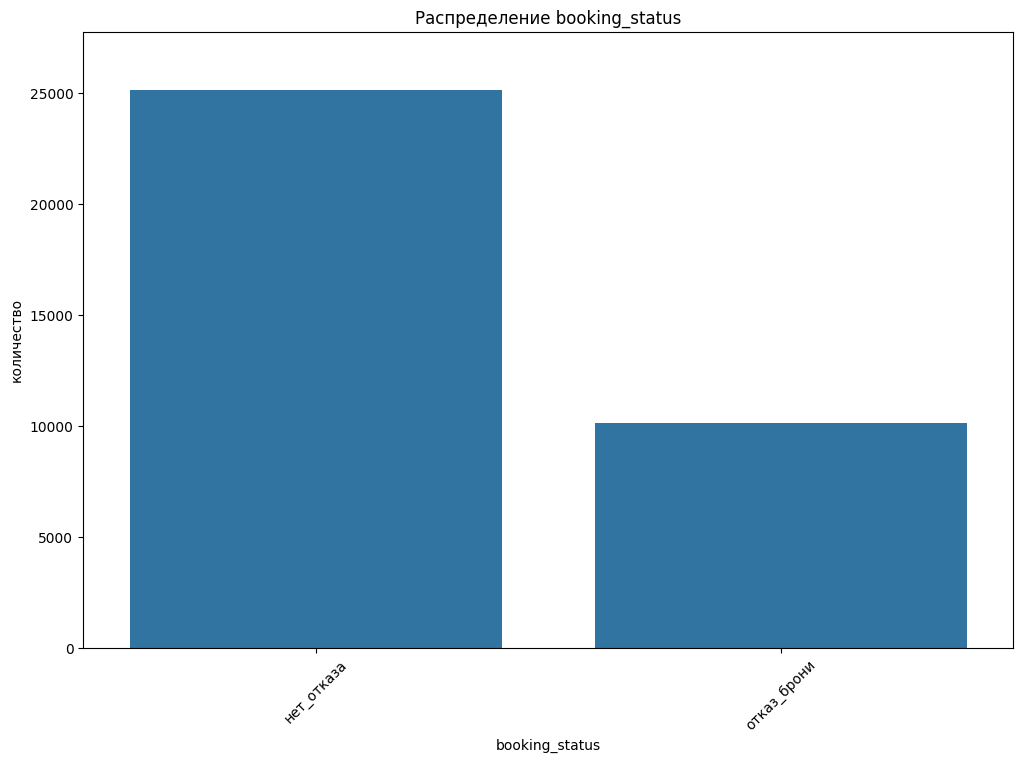

In [20]:
plot_count_bars(df_hotel_bookings, target_col)

In [21]:
df_hotel_bookings[target_col].value_counts() / len(df_hotel_bookings[target_col]) * 100

booking_status
нет_отказа     71.240203
отказ_брони    28.759797
Name: count, dtype: float64

Анализ:
- классы внутри таргета распределеные неравномерно 
- Дисбаланс 71/29%

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

#### Категориальные признаки

In [22]:
# исключение технических признаков id 
no_analyse_col_feats = ['booking_id', 'booking_date']
cat_cols_feat = [col for col in cat_cols_feat if col not in no_analyse_col_feats]
cat_cols_feat

['sales_channel', 'meal_plan', 'room_type']

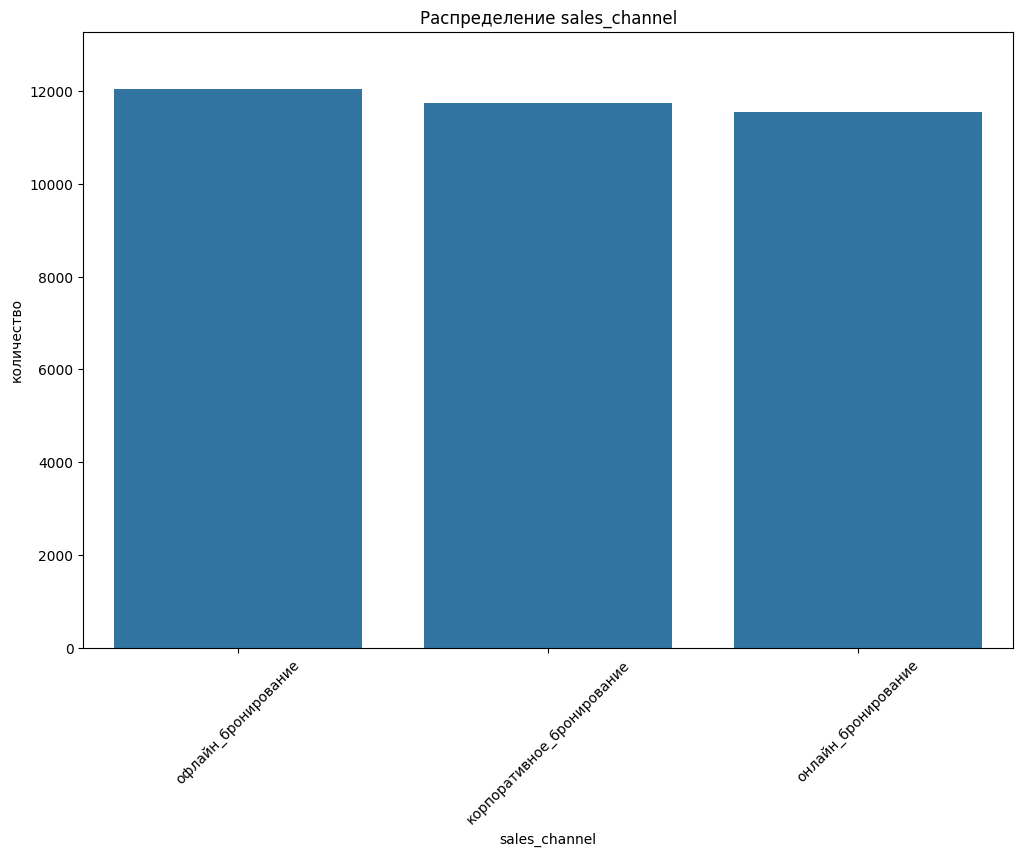

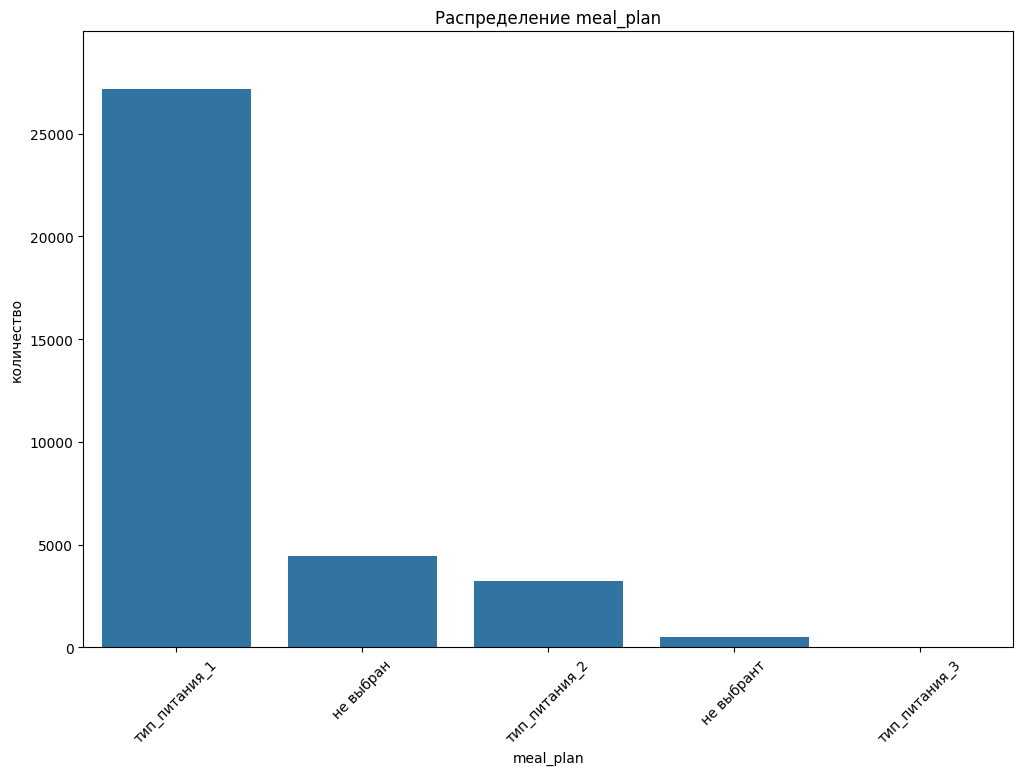

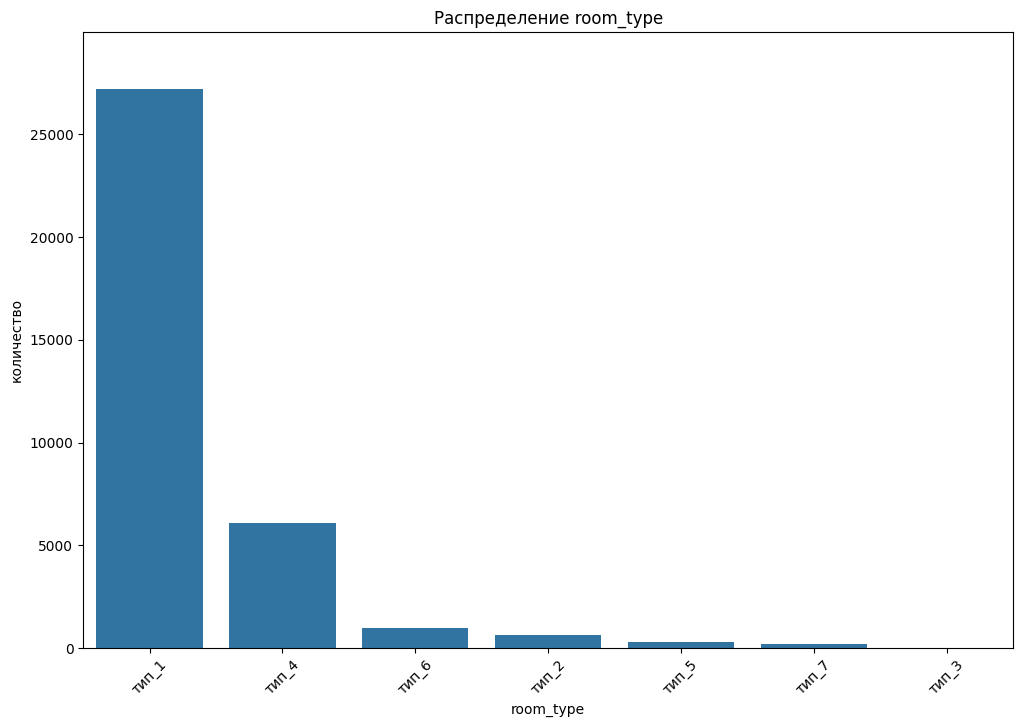

In [23]:
for name in cat_cols_feat:
    plot_count_bars(df=df_hotel_bookings, col_name=name)

Анализ:
- sales_channel: по способу оформления брони распределение равномерное
- meal_plan: 
    - По типу питания существенно лидирует 1 тип. 
    - Присутствует категория с опечаткой в названии. Стоит объединить `не выбран` и `не выбрант` в один признак. Он будет второй по популярности
    - 2ой тип в 9 раз уступает по популярности 1ому
    - 3 тип крайне малочисленный - всего 7шт, в то время как 1ого типа около 27к

- room_type: 
    - существенно преобладает тип_1 - 27к
    - на втором месте тип_4 с 6к
    - остальные менее 1к

#### Количественные признаки 

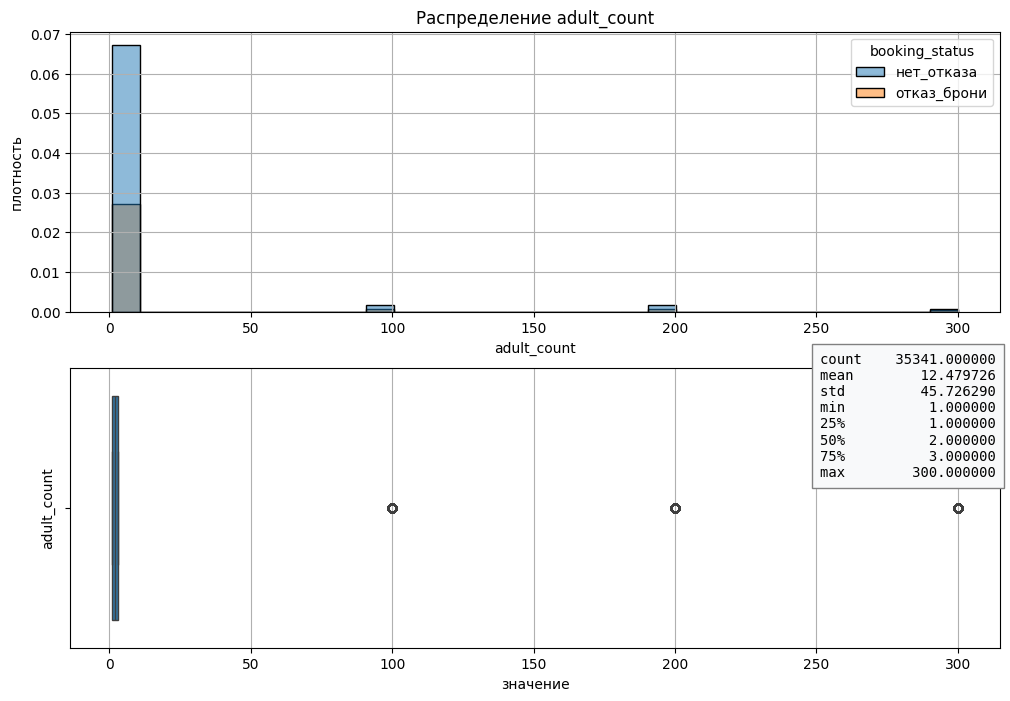

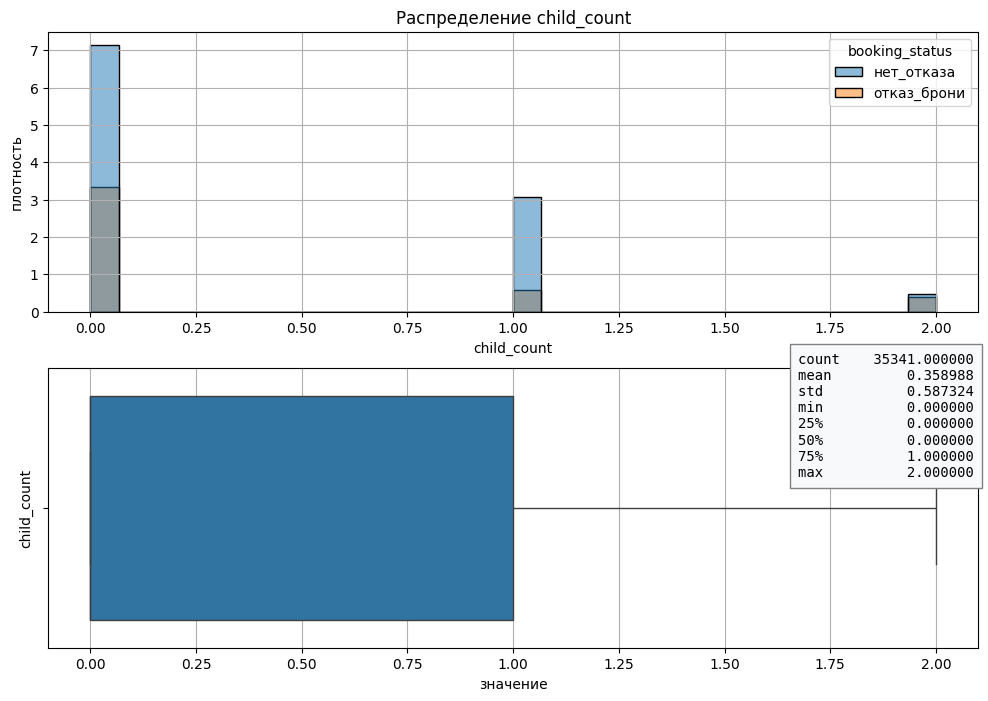

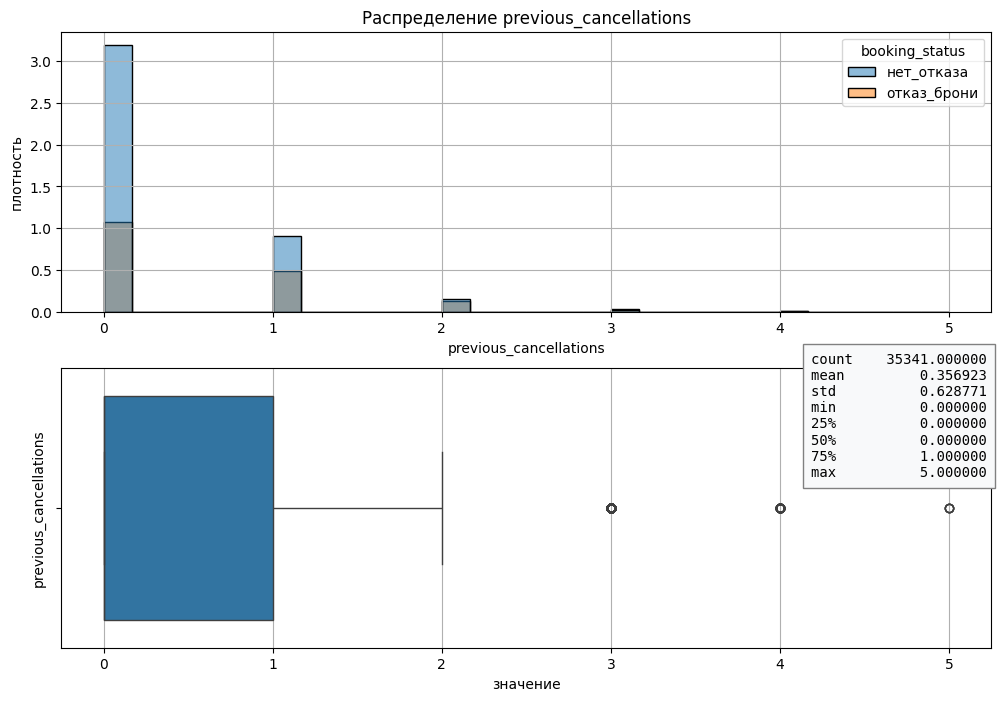

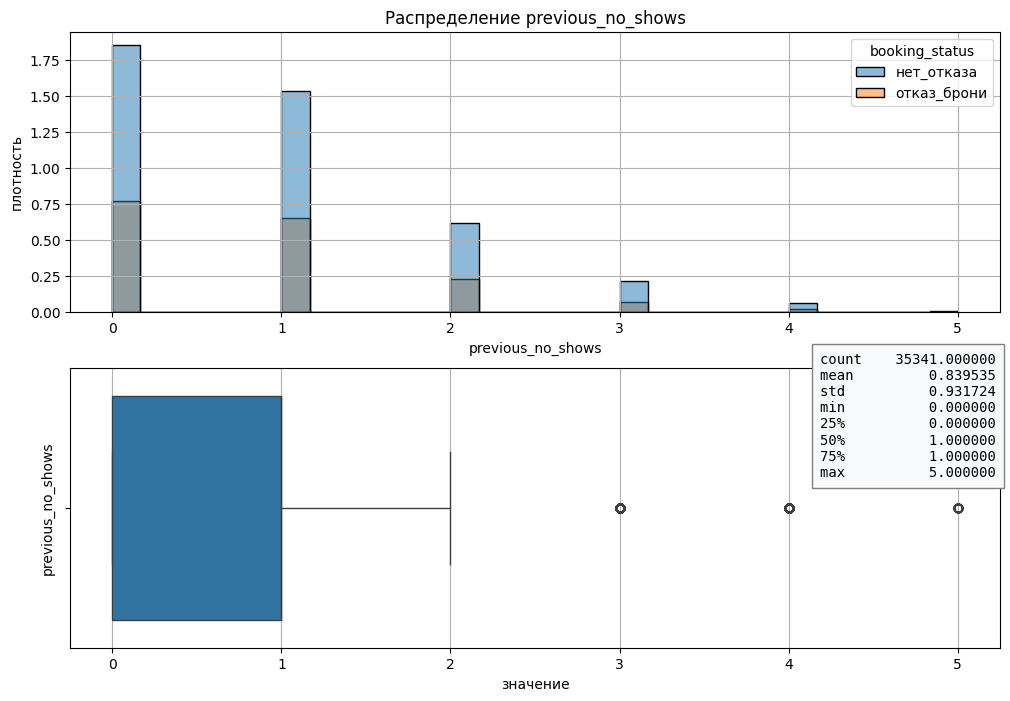

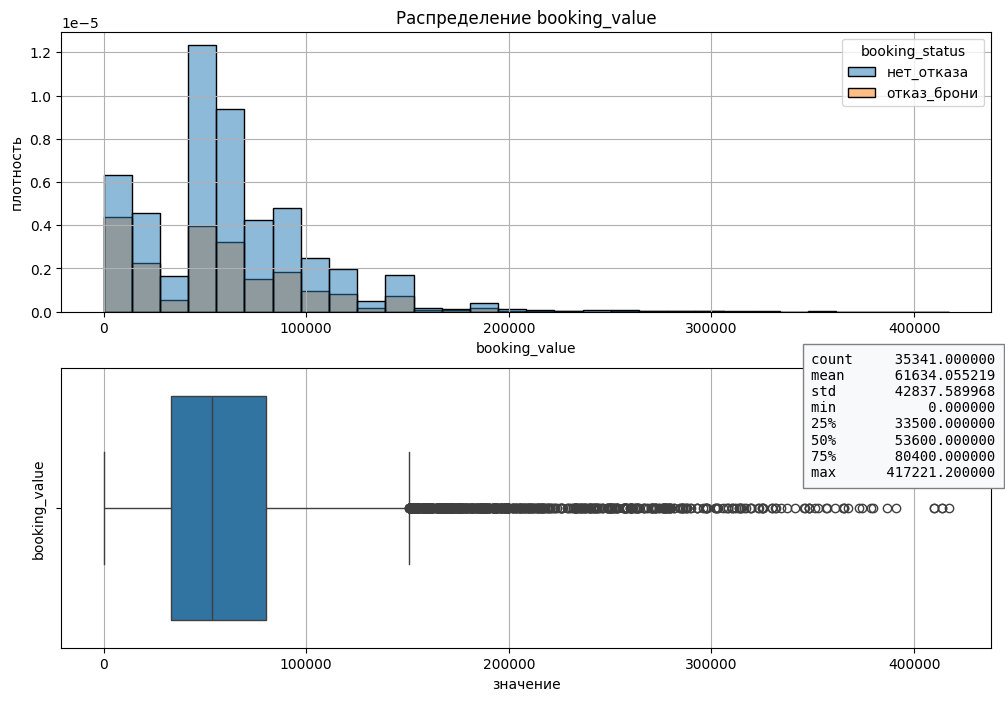

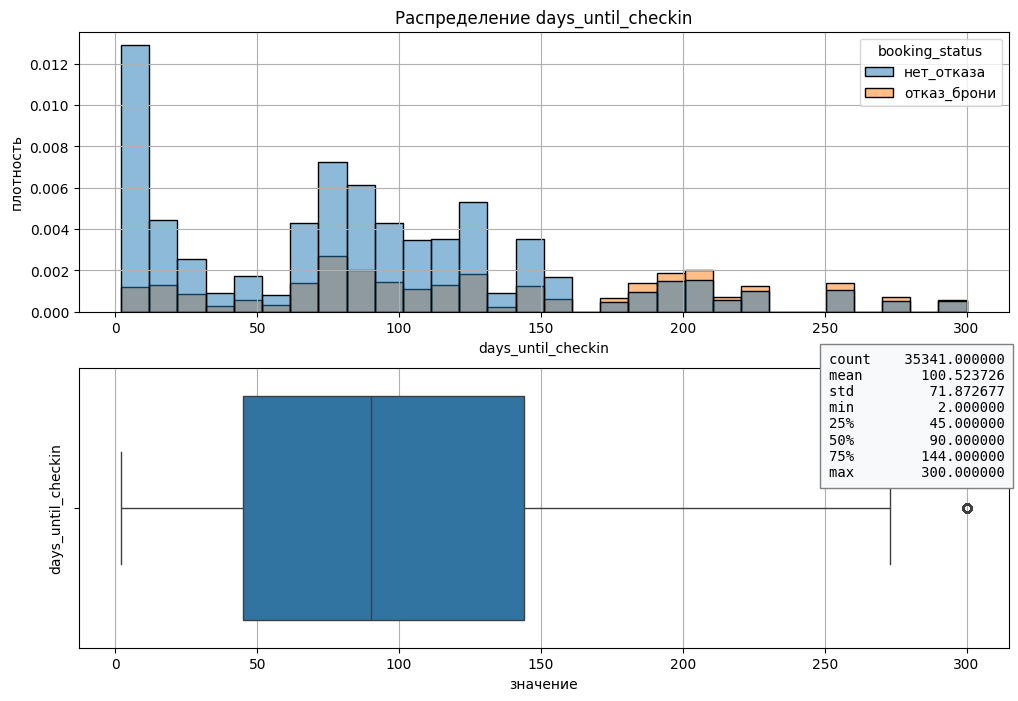

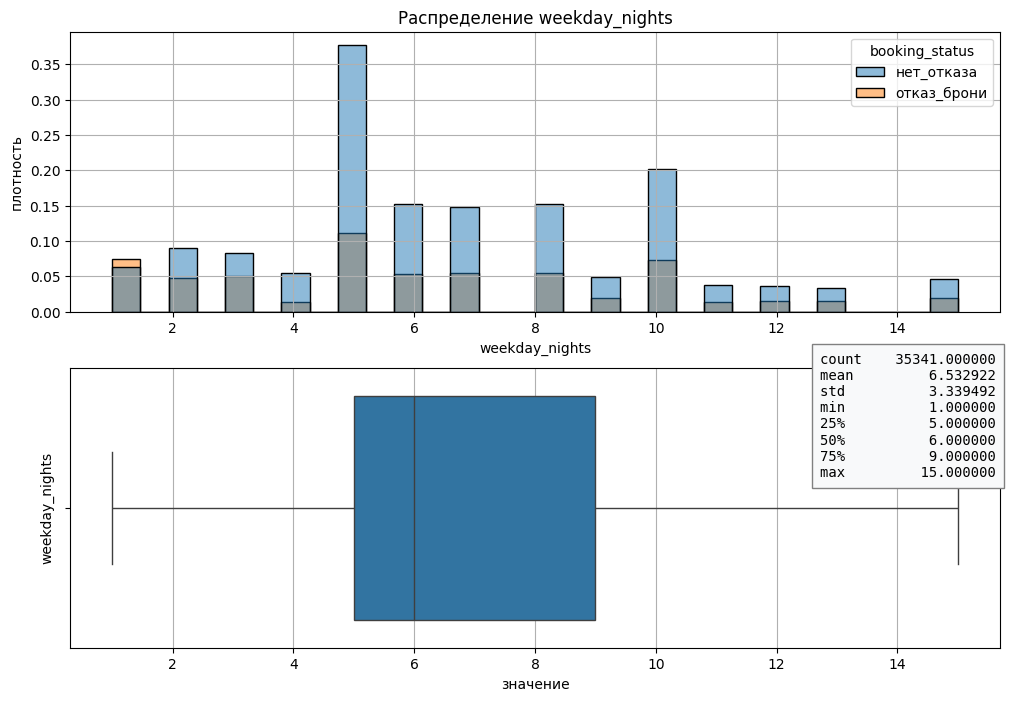

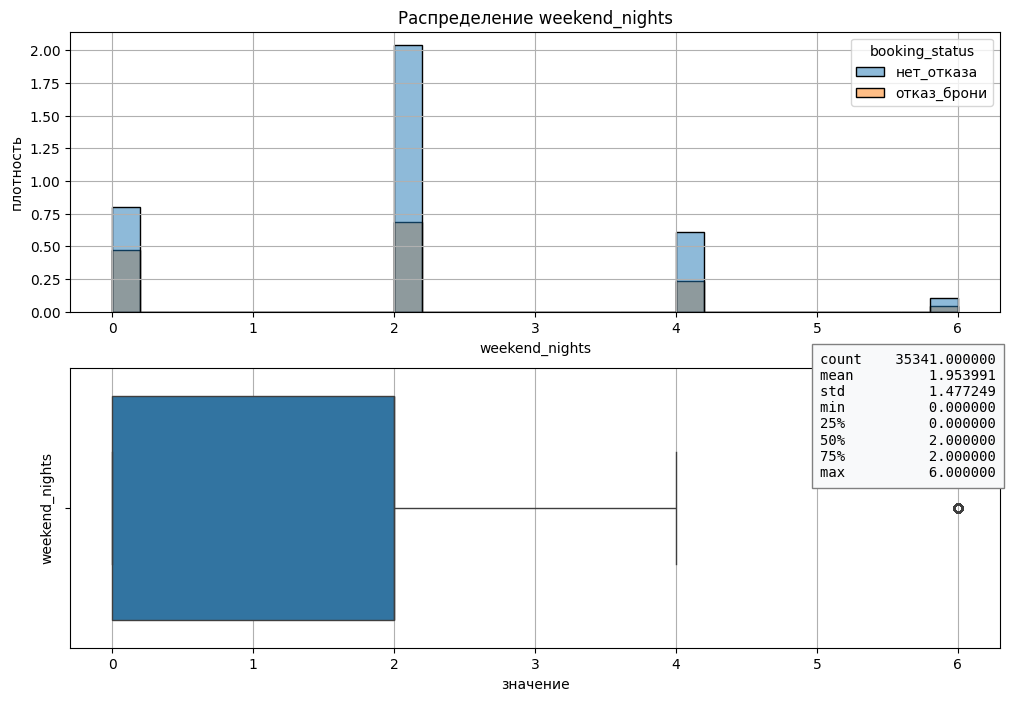

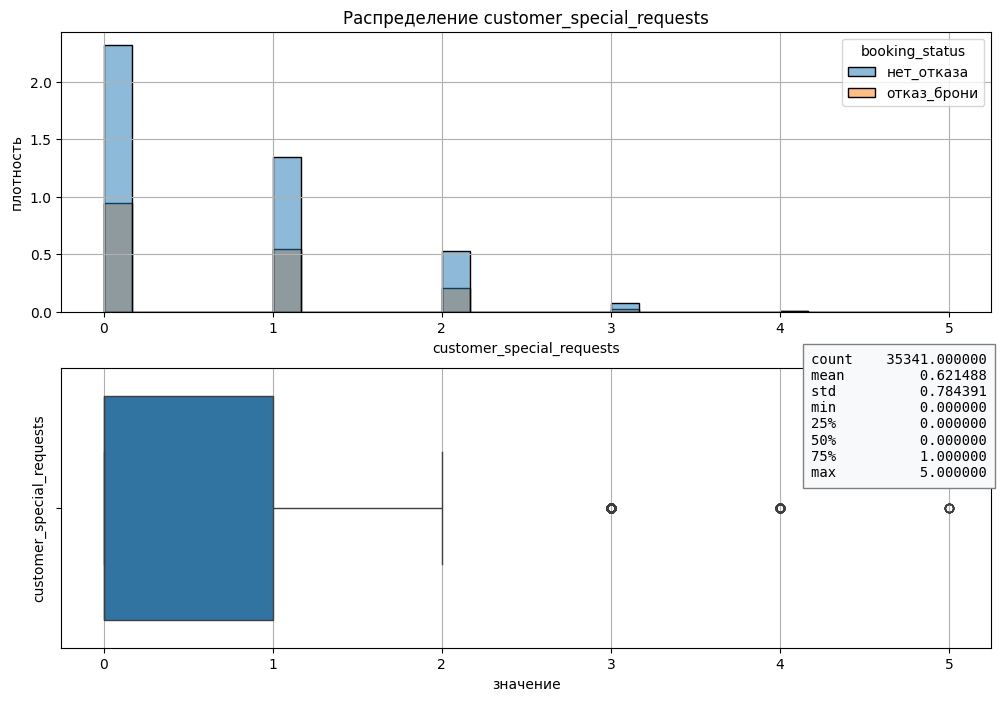

In [24]:
for name in num_cols_feat:
    plot_hist_box(df=df_hotel_bookings, feature_name=name, hue=target_col)

Анализ:
- adult_count: в основном 1-3 взрослых в номерах. Значения 100,200,300 скорее всего являются ошибочными. Необходимо провести корректировку.
- child_count: более 50% заселений без детей, с 1-2 детьми заселяются гораздо реже. С 2мя детьми доля отказов существенно выше, чем в других случаях
- previous_cancellations: экспоненциально убывает количество предыдущих отмен броней. При этом доля отмен растет - чем больше в прошлом было отмен, тем вероятней сейчас тоже отменит
- previous_no_shows: экспоненциально убывает количество неподтвержденных броней. 
- booking_value: итоговая стоимость бронирования сосредоточена в интервале 0-200к. Значения с нулевой стоимостью, предположительно, являются ошибками записи данных и требуют дополнительного исследования. Присутствуют малочисленные выбросы +400к
- days_until_checkin: в основном бронируют номера незадолго до заселения (пик по частоте 2-10 дней). При этом доля отмен выше среди длительных сроков броней.
- weekend_nights: наиболее часто 5 дней. Наиболее высокая доля отказов при 1 ночи
- weekday_nights: в основном 2 дня. Явных зависимостей с таргетом не видно
- customer_special_requests: кол-во просьб убывает экспоненциально.  Явных зависимостей с таргетом не прослеживается

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Обрати внимание на группы в adult_count.\
Здесь явная ошибка записи. Нужно убрать нули у аномальных значений. 300 → 3</font>

</span><br><span style="color: purple; font-weight: bold">Я предположил, что это корпоративные брони. Но, действительно, похоже больше на опечатки, требующие корректировок. </span>

**корректировка ошибок записи для adult_count**

- значения 100, 200, 300 в adult_count являются ошибочными. Предлагается провести корректировку, убрав лишние нули

In [25]:

df_hotel_bookings['adult_count'] = df_hotel_bookings['adult_count'].replace({100: 1, 200: 2, 300: 3})

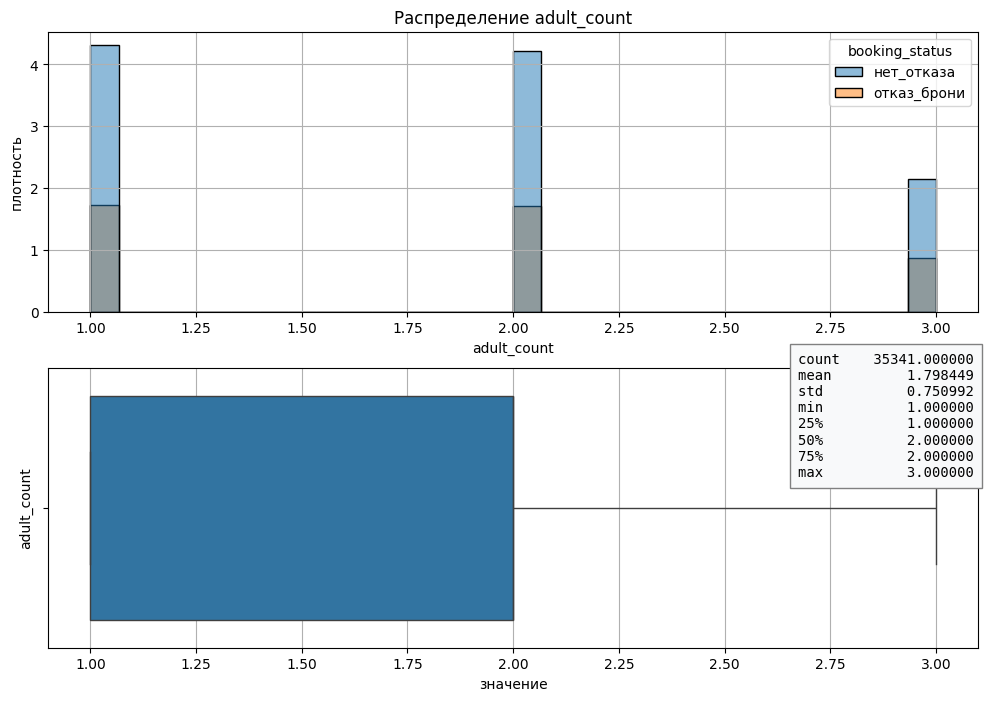

In [26]:
plot_hist_box(df=df_hotel_bookings, feature_name='adult_count', hue=target_col)

Анализ:
- распределение по значению adult_count после исправления ошибок записи  не имеет особенностей. Чаще всего заселяются 1-2 человека. Доля отмен не меняется

**Корректировка значений в booking_value**
- нулевая стоимость является ошибкой записи. Предлагается провести корректировку таких значений

In [27]:
# доля нулевых значений
zero_book_value_mask = df_hotel_bookings['booking_value'] == 0

zero_book_value_mask.mean() * 100


np.float64(4.020825669901814)

Доля ошибочных данных мала: 4%. Принято решение исключить такие строки из анализа

In [28]:
df_hotel_bookings = df_hotel_bookings[~zero_book_value_mask]

### Таблица **hotel_reviews**

In [29]:
df_hotel_reviews.columns

Index(['customer_id', 'booking_id', 'review_date', 'stay_rating',
       'review_text'],
      dtype='object')

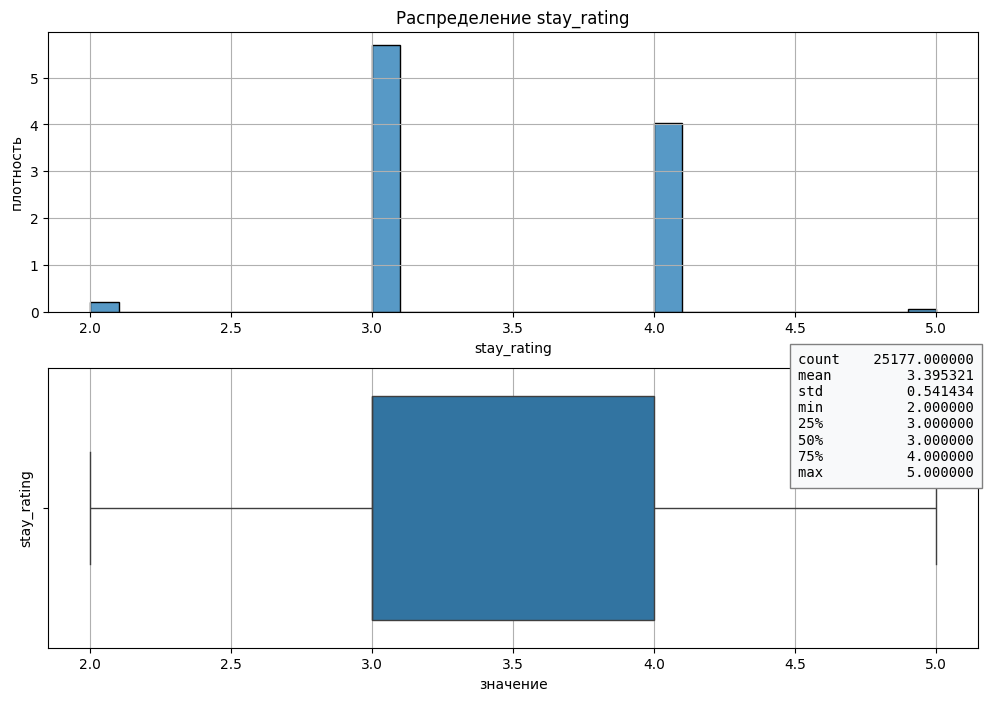

In [30]:
plot_hist_box(df=df_hotel_reviews, feature_name='stay_rating')

In [31]:
# доля уникальных отзывов
df_hotel_reviews['review_text'].nunique() / len(df_hotel_reviews) * 100

56.2140048456925

In [32]:
df_hotel_reviews['review_text'].value_counts()

review_text
Отличный отель! хорошие виды из окон.                                                                                                                                  42
Отличный отель! достаточное освещение.                                                                                                                                 40
Отличный отель! приятная музыка в лобби.                                                                                                                               38
Отличный отель! качественные продукты на завтрак.                                                                                                                      37
Отличный отель! вежливый персонал.                                                                                                                                     37
                                                                                                                                          

Анализ:
- stay_rating: основные оценки 3,4. 2,5 - редко ставят. 
- review_text: уникальных отзывов около 56%. Большое количество отднотипных отзывов существенно упростит векторизацию и формирование новых признаков.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.</font>

</span><br><span style="color: purple; font-weight: bold">Внес правки: строки с нулевой стоимостью брони исключены из таблицы </span>

### Объединение таблиц

In [33]:
# чистка от явных дублей
init_len_df_hotel_bookings = len(df_hotel_bookings)

df_hotel_bookings.drop_duplicates(inplace=True)

print('Потери при устранении дублей (%): ', (init_len_df_hotel_bookings - len(df_hotel_bookings)) / init_len_df_hotel_bookings * 100 )

Потери при устранении дублей (%):  13.018867924528301


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [34]:
# Преобразование типов
df_hotel_bookings['booking_date'] = pd.to_datetime(df_hotel_bookings['booking_date'])
df_hotel_reviews['review_date'] = pd.to_datetime(df_hotel_reviews['review_date'])

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [35]:
df_hotel_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


In [36]:
df_hotel_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [37]:
booking_customer_map = (
    df_hotel_reviews[['booking_id', 'customer_id']]
    .dropna(subset=['booking_id', 'customer_id'])
    .drop_duplicates(subset='booking_id')
)

# customer_id используется только как технический ключ для исторических признаков.
# Сам customer_id дальше удаляется из признакового пространства.
df_hotel_bookings_client_ids = df_hotel_bookings.merge(
    booking_customer_map,
    how='left',
    on='booking_id',
)
df_hotel_bookings_client_ids.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id
0,INN00000,2020-07-08,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0,C0001
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1,C0001
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0,C0001
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0,C0002
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1,C0003


In [38]:
bookings_for_asof = (
    df_hotel_bookings_client_ids
    .sort_values(by=['booking_date', 'customer_id'])
    .reset_index(drop=True)
)

reviews_for_asof = (
    df_hotel_reviews
    .dropna(subset=['customer_id', 'review_date'])
    .sort_values(by=['customer_id', 'review_date'])
    .copy()
)

reviews_for_asof = (
    reviews_for_asof
    .drop(columns='booking_id')
    .sort_values(by=['review_date', 'customer_id'])
    .reset_index(drop=True)
)

df_total = pd.merge_asof(
    bookings_for_asof,
    reviews_for_asof,
    left_on='booking_date',
    right_on='review_date',
    direction='backward',
    by='customer_id',
    allow_exact_matches=False,
)

get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67000.0,...,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71200.0,...,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
2,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6700.0,...,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,...,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN
4,INN17387,2017-01-01,офлайн_бронирование,2,0,True,1,1,нет_отказа,73700.0,...,9,2,тип_питания_1,False,тип_1,2,C9324,NaT,NaN,NaN


,Метрика,Значение
0,Строк,29504.0
1,Колонок,21.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,7.0
4,Числовых колонок,10.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
review_text,object,21483,72.81,5925
review_date,datetime64[ns],21483,72.81,2042
stay_rating,float64,21483,72.81,5
customer_id,object,8492,28.78,13082
booking_id,object,0,0.00,29504
booking_date,datetime64[ns],0,0.00,2440
booking_value,float64,0,0.00,1765
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
room_type,object,0,0.00,7


Типы колонок


,Категориальные колонки,Числовые колонки
0,booking_id,adult_count
1,sales_channel,child_count
2,booking_status,previous_cancellations
3,meal_plan,previous_no_shows
4,room_type,booking_value
5,customer_id,days_until_checkin
6,review_text,weekday_nights
7,NaN,weekend_nights
8,NaN,customer_special_requests
9,NaN,stay_rating


--------------------------------------------------


In [39]:
# проверка правила присоединения
matched_reviews = df_total[df_total['review_date'].notna()].copy()

future_or_current_review_count = (
    matched_reviews['review_date'] >= matched_reviews['booking_date']
).sum()
future_or_current_review_count

np.int64(0)

Нет строк, нарушающих правило присоединения отзывов к данным о брони.

Следовательно, формирование итоговой таблицы корректно.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
`shift(-1)` берёт следующую бронь:\
shift(-1) сдвигает вперёд — для каждого отзыва берётся booking_id следующей брони клиента. Затем мерж привязывает этот отзыв к следующей брони.\
Что происходит: отзыв написан после проживания → привязать его к следующей брони как "предыдущий опыт". Логика интересная, но реализация некорректная по нескольким причинам:

- Не проверяется что review_date < booking_date следующей брони — отзыв может быть написан после даты следующей брони
- Если у клиента только одна бронь — shift(-1) даст NaN
- Мерж по future_booking_id — ненадёжная связь
</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>В библиотеке pandas для этого есть специальная мощная функция — pd.merge_asof. Она идеально подходит для сопоставления событий во времени.</font>

</span><br><span style="color: purple; font-weight: bold">Внес правки: использовал pd.merge_asof </span>

Итог:
- проведено преобразование типов данных к datetime в таблицах перед соединением, проведена сортировка по датам
- потери при устранении дублей в таблице hotel_bookings: 13%
- создана общая таблица с информацией о бронировании и отзывах клиентов
- исправлены ошибки в данных столбцов: booking_value и adults_count
- информация по отзывам присоединена по правилу: ближайший отзыв клиента с прошлой брони номера
- в итоговой таблице 71% записей о бронировании без отзывов и рейтингов. Это существенное количество. Пропуски оставляются как есть, модели бустинга умеют работать с пропусками из коробки

### Создание новых признаков

In [40]:
# сезонность в виде месяца планируемого заезда
df_total = df_total.sort_values(by='booking_id')
df_total['checkin_month'] = (df_total['booking_date'] + pd.to_timedelta(df_total['days_until_checkin'], unit='days')).dt.month

In [41]:
# лояльность клиента: кол-во предыдущих броней
df_total = df_total.sort_values(by=['customer_id', 'booking_date']).copy()
known_customer_mask = df_total['customer_id'].notna()

df_total['prev_booking_count'] = 0
df_total.loc[known_customer_mask, 'prev_booking_count'] = (
    df_total.loc[known_customer_mask]
    .groupby('customer_id')
    .cumcount()
)
df_total['prev_booking_count'] = df_total['prev_booking_count'].astype('int64')

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Датафрейм должен быть отсортирован по `booking_date` перед вычислением .cumcount()</span>

</span><br><span style="color: purple; font-weight: bold">Добавил сортировку </span>

#### Предобработка текста

In [42]:
# Загрузка стоп-слов и пунктуации
nltk.download('stopwords')
nltk.download('punkt')
nltk.download("punkt_tab")
stop_words = set(stopwords.words('russian'))
punctuation = set(string.punctuation)

morph = pymorphy3.MorphAnalyzer()

def preprocess_text(text):

    words = word_tokenize(text.lower())
    lemmatized_words = [morph.parse(word)[0].normal_form for word in words]
    filtered_words = [
        word
        for word in lemmatized_words
        if word not in stop_words and word not in punctuation
    ]
    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/a.plahotniuc/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [43]:
df_total['review_text'] = df_total['review_text'].fillna('').apply(preprocess_text)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очистка сделана верно! Мы оставили только символы алфавита и привели к нижнему регистру!\
Убрали частые неинформативные слова!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Векторизатор нельзя обучать на всём корпусе текстов (до разделения на выборки)\
На данном этапе достаточно сконфигурировать TfidfVectorizer, а обучать внутри кросс-валидации.</font>

</span><br><span style="color: purple; font-weight: bold">Оставил только предобработку текста. Инициализацию векторизатора перенес ближе к кросс-валидации </span>

Итог:
- сформировано 2 признака на основе информации об отзывах и предыдущих бронях клиентов: 
    - checkin_month - отражает сезонность, 
    - prev_booking_count - отражает лояльность, 
- признаки, основанные на текстах отзывов создаются в пайплайне обучения 

### Предобработка по результатам ИАД

In [44]:
# чистка от неинформативных признаков
df_total = df_total.drop(columns=['booking_id', 'customer_id', 'review_date'])

In [45]:
# правка опечаток
df_total['meal_plan'] = df_total['meal_plan'].replace('не выбрант', "не выбран")
df_total['meal_plan'].unique()

array(['тип_питания_2', 'тип_питания_1', 'не выбран', 'тип_питания_3'],
      dtype=object)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

In [46]:
dupl_part = df_total.duplicated().sum() / len(df_total) * 100

df_total = df_total.drop_duplicates()
print('Потери при очистке дублей (%): ', dupl_part)

Потери при очистке дублей (%):  0.0


In [47]:
cat_cols, num_cols = get_cat_num_cols(df_total)

In [48]:
for col in cat_cols:
	# приведение всех категориальных признаков к pd.categorical
	df_total[col] = df_total[col].astype('category')

In [49]:
# приведение таргета к бинарному виду
df_total["booking_status"] = (
    df_total["booking_status"]
    .map({"отказ_брони": 1, "нет_отказа": 0})
    .astype("int8")
)
df_total["booking_status"].unique()

array([0, 1], dtype=int8)

In [50]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29504 entries, 22151 to 29503
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_date               29504 non-null  datetime64[ns]
 1   sales_channel              29504 non-null  category      
 2   adult_count                29504 non-null  int64         
 3   child_count                29504 non-null  int64         
 4   returning_customer         29504 non-null  bool          
 5   previous_cancellations     29504 non-null  int64         
 6   previous_no_shows          29504 non-null  int64         
 7   booking_status             29504 non-null  int8          
 8   booking_value              29504 non-null  float64       
 9   days_until_checkin         29504 non-null  int64         
 10  weekday_nights             29504 non-null  int64         
 11  weekend_nights             29504 non-null  int64         
 12  meal_

### Корреляционный анализ

In [51]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [52]:
corr_matrix = get_corr_matrix(
    data=df_total, 
    feat_cols=num_cols_feat + cat_cols_feat + [target_col], 
    num_cols=num_cols_feat + [target_col]
)

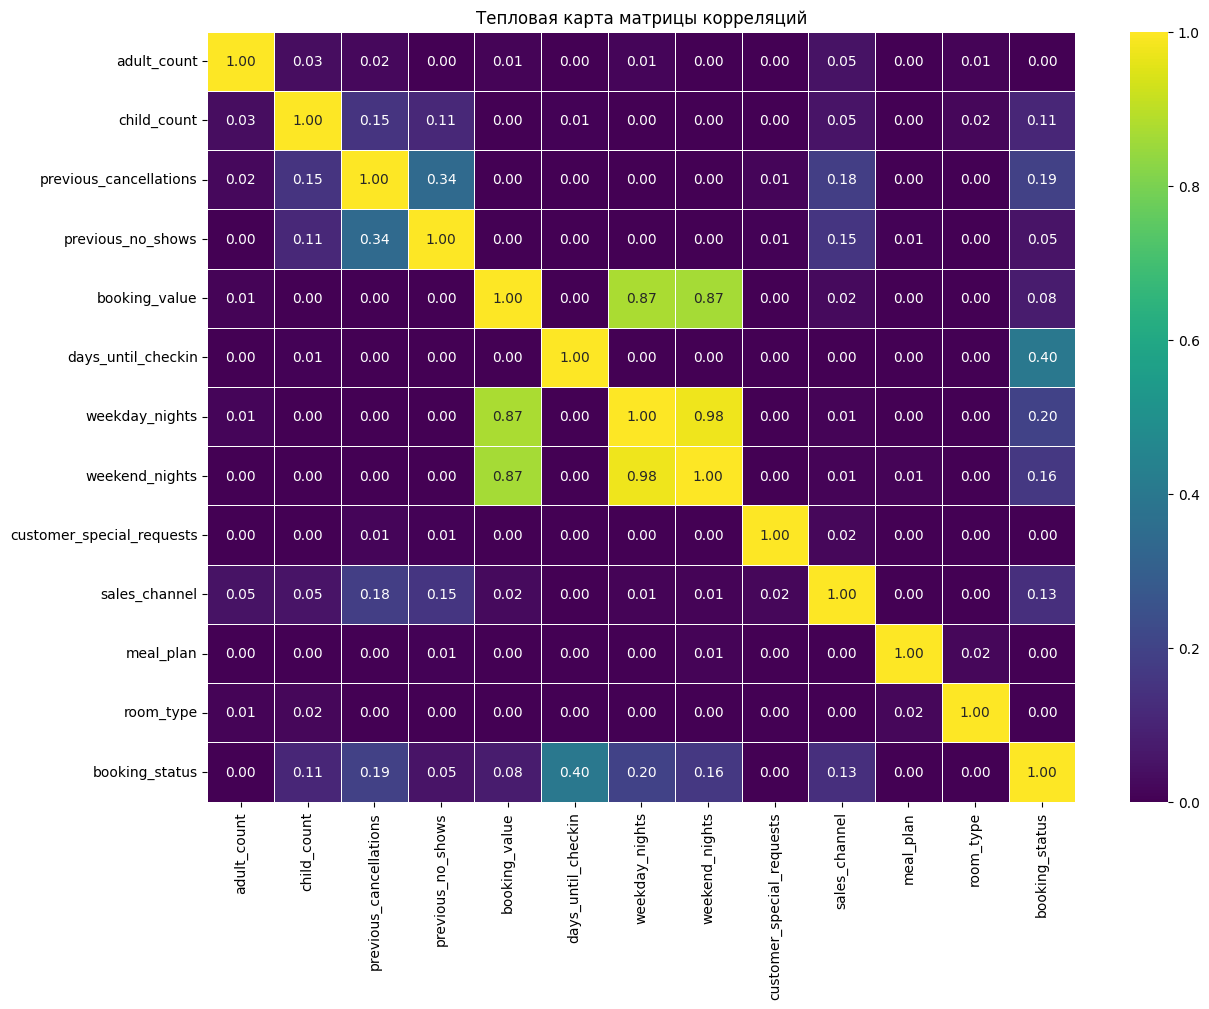

In [53]:
plot_corr_matrix(corr_matrix)

Анализ:
- признаки weekday_nights и weekend_nights сильно скоррелированы друг с другом: корреляция выше 0.95. Ожидаемо, поскольку люди подряд бронируют отель на будни и выходные дни. Чтобы бороться с мультиколлинеарностью при обучении стоит добавлять коэффициенты регуляризации.
- стоимость брони выскоко скоррелировано с кол-вом ночей (длительностью пребывания). Ожидаемо, поскольку чем дольше клиент пребывает, тем дороже бронь
- с таргетом больше всего скоррелирован признак days_until_checkin. Можно предположить, что чем больше времени до брони, тем вероятней отмена.

### Анализ итоговой таблицы

In [54]:
get_base_df_info('df_total', df_total)

Общая информация о датафрейме df_total


,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,stay_rating,review_text,checkin_month,prev_booking_count
22151,2020-07-08,корпоративное_бронирование,3,0,False,0,0,0,6700.0,21,1,0,тип_питания_2,False,тип_1,0,NaN,,7,0
27513,2021-09-19,корпоративное_бронирование,3,0,True,0,1,0,62300.0,15,5,2,тип_питания_2,False,тип_1,1,3.0,неплохо тихо спокойно отсутствие фен номер кондиционер справляться тяжело номер,10,1
29029,2022-11-19,корпоративное_бронирование,3,0,True,0,2,0,46900.0,96,5,2,тип_питания_1,False,тип_1,0,3.0,неплохо красивый оформление территория неработающий лифт,2,2
490,2017-02-11,онлайн_бронирование,2,0,False,0,0,0,53600.0,150,6,2,тип_питания_1,False,тип_1,0,NaN,,7,0
12377,2019-03-06,корпоративное_бронирование,1,0,True,1,1,0,46900.0,96,5,2,тип_питания_1,False,тип_1,1,NaN,,6,0


,Метрика,Значение
0,Строк,29504.0
1,Колонок,20.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,4.0
4,Числовых колонок,13.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
stay_rating,float64,21483,72.81,5
review_text,category,0,0.00,5924
booking_date,datetime64[ns],0,0.00,2440
booking_value,float64,0,0.00,1765
days_until_checkin,int64,0,0.00,79
weekday_nights,int64,0,0.00,14
checkin_month,int32,0,0.00,12
room_type,category,0,0.00,7
previous_cancellations,int64,0,0.00,6
previous_no_shows,int64,0,0.00,6


Типы колонок


,Категориальные колонки,Числовые колонки
0,sales_channel,adult_count
1,meal_plan,child_count
2,room_type,previous_cancellations
3,review_text,previous_no_shows
4,NaN,booking_status
5,NaN,booking_value
6,NaN,days_until_checkin
7,NaN,weekday_nights
8,NaN,weekend_nights
9,NaN,customer_special_requests


--------------------------------------------------


Анализ:
- итоговая таблица состоит из данных о бронировании и информации об отзывах клиентов
- дублей нет. Потери при очистке менее 0.1%
- исправлены ошибки в данных столбцов: booking_value и adults_count
- информация по отзывам присоединена по правилу: ближайший отзыв клиента с прошлой брони номера
- пропуски есть в признаках prev_booking_count и stay_rating: 71%. Вызвано это тем, что не у всех клиентов есть история броней и не все оставляют отзывы. Процент существенный, оставляем как есть. Модели бустинга умеют работать с пропусками.
- текстовые данные предобработаны: приведены к нижнему регистру и очищены от стоп-слов
- таблица содержит новые признаки checkin_month - отражает сезонность, prev_booking_count - отражает лояльность клиентов.
- таргет "booking_status" преобразован к бинарному флагу: 1 - отмена брони, 0 - бронь подтверждена

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> Нужно провести анализ корреляций, как стандартный шаг ИАД.</font>

</span><br><span style="color: purple; font-weight: bold"> Провел корреляционный анализ </span>

## Этап 2: моделирование

### Обучение и оптимизация модели

### Разделение на выборки


In [74]:
# сортировка по времени
df_total = df_total.sort_values(by='booking_date').reset_index(drop=True)

In [75]:
X = df_total.drop(columns='booking_status')
y = pd.Series(df_total['booking_status'], name='target')
display(X.shape, y.shape)

(29504, 19)

(29504,)

In [76]:
cat_cols, num_cols = get_cat_num_cols(df=X)
cat_cols

['sales_channel', 'meal_plan', 'room_type', 'review_text']

In [77]:
# train_calib 80% и test 20%
train_calib_size = 0.8
ds_len = X.shape[0]
train_calib_idx = int(ds_len*train_calib_size)

X_train_calib = X.iloc[:train_calib_idx]
X_test = X.iloc[train_calib_idx:]

y_train_calib = y.iloc[:train_calib_idx]
y_test = y.iloc[train_calib_idx:]

In [78]:
# train 60% и calib 20%
train_size = 0.75
ds_len = X_train_calib.shape[0]
train_idx = int(ds_len*train_size)

X_train = X_train_calib.iloc[:train_idx]
X_calib = X_train_calib.iloc[train_idx:]

y_train = y_train_calib.iloc[:train_idx]
y_calib = y_train_calib.iloc[train_idx:]

In [79]:
X_train.shape, X_calib.shape, X_test.shape

((17702, 19), (5901, 19), (5901, 19))

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Для разделения данных на выборки, нужно отсортировать данные по времени ('booking_date'), а затем разделить без перемешивания, что бы тестовая выборка была позже всех.</font>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='darkorange'>Нам нужны три выборки: обучающая, калибровочная и тестовая. `X_val` нам не нужна. В проекте требуется кросс-валидация.</font>

</span><br><span style="color: purple; font-weight: bold"> Привел в соответсвие с требованиями: train, calib, test </span>

In [80]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17702 entries, 0 to 17701
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_date               17702 non-null  datetime64[ns]
 1   sales_channel              17702 non-null  category      
 2   adult_count                17702 non-null  int64         
 3   child_count                17702 non-null  int64         
 4   returning_customer         17702 non-null  bool          
 5   previous_cancellations     17702 non-null  int64         
 6   previous_no_shows          17702 non-null  int64         
 7   booking_value              17702 non-null  float64       
 8   days_until_checkin         17702 non-null  int64         
 9   weekday_nights             17702 non-null  int64         
 10  weekend_nights             17702 non-null  int64         
 11  meal_plan                  17702 non-null  category      
 12  park

In [81]:
AVG_REV = 64_500
COST_FP = 7_000
LOST_REV = AVG_REV
PER_REBOOKING = 45_000


def inc_rev_metric(y_true, y_pred):
    """
    Финансовый результат при заданной стратегии предсказаний.

    Если y_pred состоит только из нулей, функция возвращает результат до внедрения
    модели: состоявшиеся брони дают AvgRev, отмены дают LostRev.
    Если y_pred содержит прогнозы модели, функция возвращает результат после
    внедрения: TP можно повторно продать, FP дают стоимость ошибки, FN остаются
    потерянной выручкой.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    ir = (
        (tp * PER_REBOOKING)
        + (tn * AVG_REV)
        - (fp * COST_FP)
        - (fn * LOST_REV)
    )
    return ir


def rel_inc_rev_metric(y_true, y_pred_prev, y_pred_new):
    prev_ir = inc_rev_metric(y_true, y_pred_prev)
    new_ir = inc_rev_metric(y_true, y_pred_new)

    if prev_ir == 0:
        return np.nan
    return (new_ir - prev_ir) / prev_ir * 100


def evaluate_model(y_true, y_pred):
    # макро-усреднение лучше работает для несбалансирвоанных данных 
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_binary': precision_score(
            y_true,
            y_pred,
            average='binary',
            zero_division=0,
        ),
        'recall_binary': recall_score(
            y_true,
            y_pred,
            average='binary',
            zero_division=0,
        ),
        'f1_binary': f1_score(
            y_true,
            y_pred,
            average='binary',
            zero_division=0,
        ),
        'inc_metric': inc_rev_metric(y_true, y_pred)
    }
    return metrics


def get_result_df(model_names: list[str], metric_dicts: list[dict]):
    # Преобразование результатов в датафрейм
    df_results = pd.DataFrame({
        name: {
            k: v for k, v in metric_dict.items()
        } for name, metric_dict in zip(model_names, metric_dicts)
    })
    return df_results

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>Константы можно вынести в начало модуля</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">
Усреднение `average='macro'` применяется к мультиклассовой классификации и в нашем случае нужно `average='binary'`\
При macro-подходе sklearn считает метрику отдельно для класса 0 и класса 1, а затем берет среднее арифметическое. Если твоя модель будет идеально предсказывать частый класс (заезды), но полностью провалит редкий целевой класс (отмены), метрика macro все равно покажет вполне приличный результат (около 45-50%) за счет доминирующего класса.</span>

</span><br><span style="color: purple; font-weight: bold"> Исправил усреднение  </span>

In [82]:
def add_tfidf_features(
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    text_col: str = "review_text",
    max_features: int = 100,
    min_df: int = 5,
    max_df: float = 0.8,
    ngram_range: tuple[int, int] = (1, 1),
):
    """Добавление TF-IDF-признаков."""
    X_train_base = X_train.drop(columns=text_col).copy()
    X_valid_base = X_valid.drop(columns=text_col).copy()

    tfidf = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range,
    )

    train_text = X_train[text_col].astype("string").fillna("")
    valid_text = X_valid[text_col].astype("string").fillna("")

    try:
        X_train_text = tfidf.fit_transform(train_text)
    except ValueError:
        return X_train_base, X_valid_base, None

    X_valid_text = tfidf.transform(valid_text)
    tfidf_cols = [
        f"tfidf_{word}" for word in tfidf.get_feature_names_out()
    ]

    X_train_text_df = pd.DataFrame(
        X_train_text.toarray(),
        columns=tfidf_cols,
        index=X_train.index,
    )
    X_valid_text_df = pd.DataFrame(
        X_valid_text.toarray(),
        columns=tfidf_cols,
        index=X_valid.index,
    )

    X_train_final = pd.concat([X_train_base, X_train_text_df], axis=1)
    X_valid_final = pd.concat([X_valid_base, X_valid_text_df], axis=1)

    return X_train_final, X_valid_final, tfidf

### Обучение базовой модели CatBoostClassifier

In [83]:
cbc_model_base = CatBoostClassifier(
    random_state=RANDOM_SEED,
    loss_function="Logloss",
    eval_metric="Logloss",
    early_stopping_rounds=50,
    use_best_model=True,
    verbose=False,
    n_estimators=1500
)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяешь нативную кодировку моделей.</font>

In [84]:
# --- CV-параметры ---
tscv = TimeSeriesSplit(n_splits=3, test_size=2000)

In [ ]:
def make_cv_folds(
    X_cross_val_init: pd.DataFrame,
    y_cross_val_init: pd.Series,
    splitter,
    date_col: str = "booking_date",
    text_col: str = "review_text",
    tfidf_max_features: int = 100,
):
    """
    Подготовка и кеширование фолдов для TimeSeriesSplit.
    Для сокращения вычислительных трат при оптимизации гиперпараметров модели, необходимо кешировать фолды. 
    """
    X_cross_val = X_cross_val_init.copy().reset_index(drop=True)
    y_cross_val = pd.Series(y_cross_val_init).reset_index(drop=True).rename("target")

    cross_val_data = X_cross_val.copy()
    cross_val_data["target"] = y_cross_val.to_numpy()
    cross_val_data = cross_val_data.sort_values(date_col).reset_index(drop=True)

    y_cross_val = pd.to_numeric(cross_val_data.pop("target"))
    y_cross_val = y_cross_val.astype("int8")
    technical_cols = [date_col, "booking_id", "customer_id", "review_date"]
    cols_to_drop = [col for col in technical_cols if col in cross_val_data.columns]
    X_cross_val = cross_val_data.drop(columns=cols_to_drop)

    folds = []

    for fold, (train_index, valid_index) in enumerate(splitter.split(X_cross_val), start=1):
        X_train_fold = X_cross_val.iloc[train_index].copy()
        X_valid_fold = X_cross_val.iloc[valid_index].copy()
        y_train_fold = y_cross_val.iloc[train_index]
        y_valid_fold = y_cross_val.iloc[valid_index]

        if text_col in X_train_fold.columns:
            X_train_fold, X_valid_fold, tfidf = add_tfidf_features(
                X_train_fold,
                X_valid_fold,
                text_col=text_col,
                max_features=tfidf_max_features,
            )
        else:
            tfidf = None

        cat_cols, _ = get_cat_num_cols(X_train_fold)

        folds.append({
            "fold": fold,
            "X_train": X_train_fold,
            "X_valid": X_valid_fold,
            "y_train": y_train_fold,
            "y_valid": y_valid_fold,
            "cat_cols": cat_cols,
            "tfidf": tfidf,
        })

    return folds


def predict_with_threshold(model, X, threshold=None):
    """Получить классы модели с опциональным бизнес-порогом."""
    if threshold is None:
        return model.predict(X)

    y_proba = model.predict_proba(X)
    if y_proba.ndim == 2:
        y_proba = y_proba[:, 1]

    return (y_proba >= threshold).astype(int)


In [ ]:
def cross_val_learn(
    model,
    name: str,
    X_cross_val_init: pd.DataFrame,
    y_cross_val_init: pd.Series,
    date_col: str = "booking_date",
    text_col: str = "review_text",
    tfidf_max_features: int = 100,
    threshold = None,
    cv_folds = None,
):
    """Обучение модели и оценка с помощью TimeSeriesSplit."""
    folds = cv_folds
    if folds is None:
        folds = make_cv_folds(
            X_cross_val_init=X_cross_val_init,
            y_cross_val_init=y_cross_val_init,
            splitter=tscv,
            date_col=date_col,
            text_col=text_col,
            tfidf_max_features=tfidf_max_features,
        )

    scores = []

    for fold_data in folds:
        X_train_fold = fold_data["X_train"]
        X_valid_fold = fold_data["X_valid"]
        y_train_fold = fold_data["y_train"]
        y_valid_fold = fold_data["y_valid"]
        cat_cols = fold_data["cat_cols"]

        # 3. Обучение модели
        fold_model = deepcopy(model)

        if isinstance(fold_model, CatBoostClassifier):
            fold_model.fit(
                X_train_fold,
                y_train_fold,
                eval_set=(X_valid_fold, y_valid_fold),
                cat_features=cat_cols,
            )
        else:
            fold_model.fit(
                X_train_fold,
                y_train_fold,
                eval_set=[(X_valid_fold, y_valid_fold)],
                verbose=False,
            )

        # 4. Прогнозирование
        y_pred_fold = predict_with_threshold(
            fold_model,
            X_valid_fold,
            threshold=threshold,
        )

        # 5. Оценка модели
        score = evaluate_model(y_valid_fold, y_pred_fold)

        scores.append(score)

    scores = pd.DataFrame(scores)
    result = pd.DataFrame(scores.mean(axis=0)).T
    result['name'] = name
    result['threshold'] = threshold if threshold is not None else 0.5
    return result


In [ ]:

def prepare_train_eval_features(
    X_train_init: pd.DataFrame,
    X_eval_init: pd.DataFrame,
    text_col: str = "review_text",
    tfidf_max_features: int = 100,
):
    """Подготовить признаки для финального обучения."""
    technical_cols = ["booking_date", "booking_id", "customer_id", "review_date"]
    train_cols_to_drop = [col for col in technical_cols if col in X_train_init.columns]
    eval_cols_to_drop = [col for col in technical_cols if col in X_eval_init.columns]

    X_train_model = X_train_init.drop(columns=train_cols_to_drop).copy()
    X_eval_model = X_eval_init.drop(columns=eval_cols_to_drop).copy()

    if text_col in X_train_model.columns:
        X_train_model, X_eval_model, tfidf = add_tfidf_features(
            X_train_model,
            X_eval_model,
            text_col=text_col,
            max_features=tfidf_max_features,
        )
    else:
        tfidf = None

    X_eval_model = X_eval_model.reindex(columns=X_train_model.columns)
    cat_cols, _ = get_cat_num_cols(X_train_model)

    return X_train_model, X_eval_model, cat_cols, tfidf


def transform_eval_features_with_tfidf(
    X_eval_init: pd.DataFrame,
    train_columns,
    tfidf = None,
    text_col: str = "review_text",
):
    """Применить обученный TF-IDF и выровнять признаки под train."""
    technical_cols = ["booking_date", "booking_id", "customer_id", "review_date"]
    cols_to_drop = [col for col in technical_cols if col in X_eval_init.columns]
    X_eval_model = X_eval_init.drop(columns=cols_to_drop).copy()

    if tfidf is not None and text_col in X_eval_model.columns:
        X_eval_base = X_eval_model.drop(columns=text_col).copy()
        eval_text = X_eval_model[text_col].astype("string").fillna("")
        X_eval_text = tfidf.transform(eval_text)
        tfidf_cols = [f"tfidf_{word}" for word in tfidf.get_feature_names_out()]
        X_eval_text_df = pd.DataFrame(
            X_eval_text.toarray(),
            columns=tfidf_cols,
            index=X_eval_model.index,
        )
        X_eval_model = pd.concat([X_eval_base, X_eval_text_df], axis=1)
    elif text_col in X_eval_model.columns:
        X_eval_model = X_eval_model.drop(columns=text_col)

    return X_eval_model.reindex(columns=train_columns)


def train_evaluate_tuned_model(
    model_type: str,
    best_params: dict,
    X_train_init: pd.DataFrame,
    y_train_init: pd.Series,
    X_eval_init: pd.DataFrame,
    y_eval_init: pd.Series,
    model_name: str,
    threshold = None,
    text_col: str = "review_text",
    tfidf_max_features: int = 100,
    n_estimators = None,
):
    """Обучить tuned-модель и оценить её на отложенной выборке."""
    model_params = best_params.copy()
    if threshold is None:
        threshold = model_params.pop("threshold", 0.5)
    else:
        model_params.pop("threshold", None)

    X_train_model, X_eval_model, cat_cols, tfidf = prepare_train_eval_features(
        X_train_init=X_train_init,
        X_eval_init=X_eval_init,
        text_col=text_col,
        tfidf_max_features=tfidf_max_features,
    )

    model_type = model_type.lower()
    if model_type in ["xgb", "xgboost"]:
        model = XGBClassifier(
            **model_params,
            enable_categorical=True,
            n_estimators=n_estimators or 500,
            objective="binary:logistic",
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            n_jobs=-1,
            early_stopping_rounds=30,
            tree_method="hist",
            verbosity=0,
        )
        model.fit(
            X_train_model,
            y_train_init,
            eval_set=[(X_eval_model, y_eval_init)],
            verbose=False,
        )
        best_iteration = getattr(model, "best_iteration", None)
    elif model_type in ["catboost", "cbc"]:
        model = CatBoostClassifier(
            **model_params,
            random_state=RANDOM_SEED,
            loss_function="Logloss",
            eval_metric="Logloss",
            early_stopping_rounds=50,
            use_best_model=True,
            verbose=False,
            n_estimators=n_estimators or 1500,
        )
        model.fit(
            X_train_model,
            y_train_init,
            eval_set=(X_eval_model, y_eval_init),
            cat_features=cat_cols,
        )
        best_iteration = model.get_best_iteration()
    else:
        raise ValueError("model_type должен быть 'xgb' или 'catboost'")

    y_eval_proba = model.predict_proba(X_eval_model)[:, 1]
    y_eval_pred = (y_eval_proba >= threshold).astype(int)
    metrics = evaluate_model(y_eval_init, y_eval_pred)
    metrics["name"] = model_name
    metrics["threshold"] = threshold
    metrics["best_iteration"] = best_iteration

    return {
        "model": model,
        "model_params": model_params,
        "threshold": threshold,
        "metrics": metrics,
        "y_eval_proba": y_eval_proba,
        "y_eval_pred": y_eval_pred,
        "X_train": X_train_model,
        "X_eval": X_eval_model,
        "cat_cols": cat_cols,
        "tfidf": tfidf,
    }

In [86]:
cbc_model_base_cv_result = cross_val_learn(model=cbc_model_base, name='cbc_model_base', X_cross_val_init=X_train, y_cross_val_init=y_train)
cbc_model_base_cv_result

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,name,threshold
0,0.822333,0.783978,0.545256,0.642973,8.198817e+07,cbc_model_base,0.5


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Нужна кросс-валидация со специальным Сплитером - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) с test_size=2000 . </span>
> 2. Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

</span><br><span style="color: purple; font-weight: bold"> Внес правки: теперь проводится кросс-валидация </span>

Анализ:
- модель уловила основные закономерности и не переобучилась 
- высокий accuracy ~0.82 не показателен при наличии дисбаланса 
- recall_binary: 0.54 - около половины истинных таргет меток пропускается  
- precision_binary: 0.78 - среди предсказанных отмен, действительно отмененных большинство 

Рекомендация:
- необходимо провести оптимизацию параметров, чтобы улучшить качество предсказания

### Обучение базовой модели XGBClassifier

In [89]:
xgb_model_base = XGBClassifier(
    enable_categorical=True,
    n_estimators=1500,
    objective="binary:logistic",
    random_state=RANDOM_SEED,
    eval_metric="logloss", 
    n_jobs=-1, 
    early_stopping_rounds=50       
)
xgb_model_base

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [90]:
xgb_model_base_cv_result = cross_val_learn(model=xgb_model_base, name='xgb_model_base', X_cross_val_init=X_train, y_cross_val_init=y_train)
xgb_model_base_cv_result

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,name,threshold
0,0.82,0.769271,0.553275,0.643279,8.183183e+07,xgb_model_base,0.5


Анализ:
- модель уловила основные закономерности и не переобучилась 
- схожая ситуация метрикам предсказания классов: модель часто пропускает отмены броней (recall_binary = 0.56)

Рекомендация:
- оптимизация гиперпараметров

Общая таблица

In [92]:
model_results = pd.concat([
    xgb_model_base_cv_result,
    cbc_model_base_cv_result,
], axis=0).sort_values('inc_metric', ascending=False)
model_results

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,name,threshold
0,0.822333,0.783978,0.545256,0.642973,8.198817e+07,cbc_model_base,0.5
0,0.820000,0.769271,0.553275,0.643279,8.183183e+07,xgb_model_base,0.5


Анализ:
- результаты базовых моделей близки по ключевым метрикам

### Оптимизация XGBClassifier

In [93]:
cached_xgb_cv_folds = make_cv_folds(
    X_cross_val_init=X_train,
    y_cross_val_init=y_train,
    splitter=tscv,
    tfidf_max_features=100,
)


def objective_xgb(trial):
    """
    Функция-цель для оптимизации параметров xgb
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    threshold = trial.suggest_float("threshold", 0.05, 0.95)

    fold_scores = []

    for fold_data in cached_xgb_cv_folds:
        model = XGBClassifier(
            **params, 
            enable_categorical=True,
            n_estimators=500,
            objective="binary:logistic",
            random_state=RANDOM_SEED,
            eval_metric="logloss", 
            n_jobs=-1, 
            early_stopping_rounds=30,
            tree_method="hist",
            verbosity=0,
        )

        model.fit(
            fold_data["X_train"],
            fold_data["y_train"],
            eval_set=[(fold_data["X_valid"], fold_data["y_valid"])],
            verbose=False,
        )

        y_valid_proba = model.predict_proba(fold_data["X_valid"])[:, 1]
        y_valid_pred = (y_valid_proba >= threshold).astype(int)
        fold_score = inc_rev_metric(fold_data["y_valid"], y_valid_pred)
        fold_scores.append(fold_score / len(fold_data["y_valid"]))

    return float(np.mean(fold_scores))

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<span style="color: red">Здесь то же нужна кросс-валидация. </span>

</span><br><span style="color: purple; font-weight: bold"> Исправил. Обучение начало слишком долго идти, поэтому потребовалось заранее подхотовить фолды для кросс-валидации </span>

In [94]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

In [95]:
# запуск оптимизации
study_xgb = optuna.create_study(direction="maximize", sampler=sampler) 
study_xgb.optimize(
    objective_xgb,
    n_trials=30,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=-1
) 

[I 2026-07-03 15:34:11,013] A new study created in memory with name: no-name-300ac7ad-1ed8-4c60-9900-6c3c938acb9f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-03 15:34:23,713] Trial 8 finished with value: 42239.666666666664 and parameters: {'learning_rate': 0.06545999395396249, 'max_depth': 7, 'gamma': 0.530141708927968, 'reg_lambda': 5.965260776218101, 'reg_alpha': 2.030502430896892, 'subsample': 0.7986248064923337, 'colsample_bytree': 0.7676560155318513, 'threshold': 0.3802902416043221}. Best is trial 8 with value: 42239.666666666664.
[I 2026-07-03 15:34:24,895] Trial 3 finished with value: 40722.583333333336 and parameters: {'learning_rate': 0.06331369570345902, 'max_depth': 5, 'gamma': 0.24484247632587658, 'reg_lambda': 1.283511109539687, 'reg_alpha': 9.106465640976213, 'subsample': 0.8563666593147103, 'colsample_bytree': 0.940870229566101, 'threshold': 0.21905596907306}. Best is trial 8 with value: 42239.666666666664.
[I 2026-07-03 15:34:31,830] Trial 5 finished with value: 39371.5 and parameters: {'learning_rate': 0.03766217376164653, 'max_depth': 7, 'gamma': 0.4223631700031208, 'reg_lambda': 2.9807614640743316, 'reg_alpha':

In [101]:
xgb_best_result = train_evaluate_tuned_model(
    model_type="xgb",
    best_params=study_xgb.best_params,
    X_train_init=X_train,
    y_train_init=y_train,
    X_eval_init=X_calib,
    y_eval_init=y_calib,
    model_name="xgb_best_opt",
    tfidf_max_features=100,
)

xgb_best_opt = xgb_best_result["model"]
xgb_best_params = xgb_best_result["model_params"]
xgb_best_threshold = xgb_best_result["threshold"]
xgb_best_opt_metrics = xgb_best_result["metrics"]
y_calib_proba_xgb_best_opt = xgb_best_result["y_eval_proba"]
y_calib_pred_xgb_best_opt = xgb_best_result["y_eval_pred"]
X_train_xgb_best_opt = xgb_best_result["X_train"]
X_calib_xgb_best_opt = xgb_best_result["X_eval"]
xgb_best_tfidf = xgb_best_result["tfidf"]

xgb_best_opt_metrics

{'accuracy': 0.8081681071004915,
 'precision_binary': 0.6432912575970079,
 'recall_binary': 0.788538681948424,
 'f1_binary': 0.7085478887744593,
 'inc_metric': np.int64(251627000),
 'name': 'xgb_best_opt',
 'threshold': 0.33058029776685094,
 'best_iteration': 233}

In [102]:
pd.DataFrame([xgb_best_opt_metrics])

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,name,threshold,best_iteration
0,0.808168,0.643291,0.788539,0.708548,251627000,xgb_best_opt,0.33058,233


### Оптимизация модели  CatBoost


In [103]:
cached_catboost_cv_folds = make_cv_folds(
    X_cross_val_init=X_train,
    y_cross_val_init=y_train,
    splitter=tscv,
    tfidf_max_features=100,
)


def objective_catboost(trial):
    """
    Функция-цель для оптимизации параметров catboost
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1., 10.),
    }
    threshold = trial.suggest_float("threshold", 0.05, 0.95)

    fold_scores = []

    for fold_data in cached_catboost_cv_folds:
        model = CatBoostClassifier(
            **params,
            random_state=RANDOM_SEED,
            loss_function="Logloss",
            eval_metric="Logloss",
            early_stopping_rounds=50,
            use_best_model=True,
            verbose=False,
            n_estimators=1500,
        )

        model.fit(
            fold_data["X_train"],
            fold_data["y_train"],
            eval_set=(fold_data["X_valid"], fold_data["y_valid"]),
            cat_features=fold_data["cat_cols"],
        )

        y_valid_proba = model.predict_proba(fold_data["X_valid"])[:, 1]
        y_valid_pred = (y_valid_proba >= threshold).astype(int)
        fold_score = inc_rev_metric(fold_data["y_valid"], y_valid_pred)
        fold_scores.append(fold_score / len(fold_data["y_valid"]))

    return float(np.mean(fold_scores))

In [105]:
# запуск оптимизации
study_cbc = optuna.create_study(direction="maximize", sampler=sampler) 
study_cbc.optimize(
    objective_catboost,
    n_trials=30,
    show_progress_bar=True,
    gc_after_trial=True,
) 

[I 2026-07-03 15:58:12,912] A new study created in memory with name: no-name-8049b20a-1cbf-46a3-8e3c-c34f8487cecf


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-03 15:58:21,132] Trial 0 finished with value: 40131.0 and parameters: {'learning_rate': 0.022739722860291172, 'max_depth': 3, 'l2_leaf_reg': 3.7833267483002544, 'threshold': 0.5570973074117975}. Best is trial 0 with value: 40131.0.
[I 2026-07-03 15:58:26,100] Trial 1 finished with value: 31834.0 and parameters: {'learning_rate': 0.03787484525052649, 'max_depth': 4, 'l2_leaf_reg': 2.8260078264206268, 'threshold': 0.8935748777549573}. Best is trial 0 with value: 40131.0.
[I 2026-07-03 15:58:31,590] Trial 2 finished with value: 42252.25 and parameters: {'learning_rate': 0.04425845737841902, 'max_depth': 4, 'l2_leaf_reg': 5.781626467080212, 'threshold': 0.39392049220757935}. Best is trial 2 with value: 42252.25.
[I 2026-07-03 15:58:37,925] Trial 3 finished with value: 40538.25 and parameters: {'learning_rate': 0.03685627394495271, 'max_depth': 3, 'l2_leaf_reg': 5.41230668144839, 'threshold': 0.22688100065277242}. Best is trial 2 with value: 42252.25.
[I 2026-07-03 15:58:49,513] 

In [107]:
catboost_best_result = train_evaluate_tuned_model(
    model_type="catboost",
    best_params=study_cbc.best_params,
    X_train_init=X_train,
    y_train_init=y_train,
    X_eval_init=X_calib,
    y_eval_init=y_calib,
    model_name="catboost_best_opt",
    tfidf_max_features=100,
)

catboost_best_opt = catboost_best_result["model"]
catboost_best_params = catboost_best_result["model_params"]
catboost_best_threshold = catboost_best_result["threshold"]
catboost_best_opt_metrics = catboost_best_result["metrics"]
y_calib_proba_catboost_best_opt = catboost_best_result["y_eval_proba"]
y_calib_pred_catboost_best_opt = catboost_best_result["y_eval_pred"]
X_train_catboost_best_opt = catboost_best_result["X_train"]
X_calib_catboost_best_opt = catboost_best_result["X_eval"]
catboost_best_tfidf = catboost_best_result["tfidf"]

catboost_best_opt_metrics

{'accuracy': 0.8130825283850195,
 'precision_binary': 0.651844843897824,
 'recall_binary': 0.7896848137535817,
 'f1_binary': 0.7141746566467997,
 'inc_metric': np.int64(253776500),
 'name': 'catboost_best_opt',
 'threshold': 0.32570367326574157,
 'best_iteration': 110}

In [108]:
pd.DataFrame([catboost_best_opt_metrics])

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,name,threshold,best_iteration
0,0.813083,0.651845,0.789685,0.714175,253776500,catboost_best_opt,0.325704,110


### Итоговая таблица

In [117]:
base_model_results_df = pd.concat(
    [
        cbc_model_base_cv_result,
        xgb_model_base_cv_result,
    ],
    axis=0,
    ignore_index=True,
).copy()
base_model_results_df["model_stage"] = "base_cv"

best_model_results_df = pd.DataFrame(
    [
        xgb_best_opt_metrics,
        catboost_best_opt_metrics,
    ]
).copy()
best_model_results_df["model_stage"] = "optimized_calib"

model_comparison_df = pd.concat(
    [base_model_results_df, best_model_results_df],
    axis=0,
    ignore_index=True,
    sort=False,
)

ordered_cols = [
    "name",
    "model_stage",
    "accuracy",
    "precision_binary",
    "recall_binary",
    "f1_binary",
    "inc_metric",
    "threshold",
    "best_iteration",
]
ordered_cols = [col for col in ordered_cols if col in model_comparison_df.columns]
remaining_cols = [col for col in model_comparison_df.columns if col not in ordered_cols]

model_comparison_df = (
    model_comparison_df[ordered_cols + remaining_cols]
    .sort_values(by="inc_metric", ascending=False)
    .reset_index(drop=True)
)

results = model_comparison_df
model_comparison_df

,name,model_stage,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,threshold,best_iteration
0,catboost_best_opt,optimized_calib,0.813083,0.651845,0.789685,0.714175,2.537765e+08,0.325704,110.0
1,xgb_best_opt,optimized_calib,0.808168,0.643291,0.788539,0.708548,2.516270e+08,0.330580,233.0
2,cbc_model_base,base_cv,0.822333,0.783978,0.545256,0.642973,8.198817e+07,0.500000,NaN
3,xgb_model_base,base_cv,0.820000,0.769271,0.553275,0.643279,8.183183e+07,0.500000,NaN


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

Итог:
- оптимизация гиперпараметров позволила улучшить ключевой финансовый показатель моделей inc_metric: показатель вырос в 3 раза
- recall_binary	f1_binary существенно повысились после оптимизации: модели стали предсказывать большую долю отмен, при этом число ложных срабатываний также выросло (уменьшен precision_binary). Общая точность предсказаний accuracy незначительно снизилась
- Объяснить снижение accuracy, recall_binary можно тем, что оптимизация шла по финансовому показателю. Точное предсказание отмены дает возможность передать номер другому клиенту и не потерять прибыль. 
- лучшее качество по ключевой метрике inc_metric показывает оптимизированная модель CatBoost

### Калибровка модели и пересчёт результатов

In [118]:
def plot_calibration_curve(y_true, y_probas: list, names: list[str], n_bins=10, title='Calibration Curve'):
    """Построение калибровочной кривой"""
    
    for y_proba, name in zip(y_probas, names):
        prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=n_bins)

        plt.plot(prob_pred, prob_true, marker='o', label=name)
    
    plt.plot([0, 1], [0, 1], linestyle='--', label='Идеальная калибровка')
    plt.xlabel('Предсказанная вероятность')
    plt.ylabel('Истинная вероятность')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [119]:
def get_calib_metrics(y_calib, model_probabilities, sort_by=['brier_score']):
    """Резельтат калибровки"""
    calibration_metrics = []
    for model_name, y_proba in model_probabilities.items():
        calibration_metrics.append({
            'model': model_name,
            'brier_score': brier_score_loss(y_calib, y_proba),
        })

    return (
        pd.DataFrame(calibration_metrics)
        .sort_values(by=sort_by, ascending=True)
        .reset_index(drop=True)
    )

In [120]:
def get_calibrated_model(estimator, X_train, y_train, cv, method='isotonic'):
    """Откалибровать модель на train с временной кросс-валидацией."""
    calibrated_model = CalibratedClassifierCV(
        estimator=estimator,
        method=method,
        n_jobs=-1,
        cv=cv,
    )
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация. с tscv.\
`X_calib` для оценки калибровки.</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

</span><br><span style="color: purple; font-weight: bold"> Исправил </span>

In [121]:
X_train_best_model, X_calib_best_model, best_model_cat_cols, best_model_tfidf = prepare_train_eval_features(
    X_train_init=X_train,
    X_eval_init=X_calib,
    tfidf_max_features=100,
)
X_test_best_model = transform_eval_features_with_tfidf(
    X_eval_init=X_test,
    train_columns=X_train_best_model.columns,
    tfidf=best_model_tfidf,
)

if xgb_best_opt_metrics['inc_metric'] >= catboost_best_opt_metrics['inc_metric']:
    best_model_type = 'xgb'
    best_model_name = 'xgb_best_opt'
    best_model_threshold = xgb_best_threshold
    best_n_estimators = getattr(xgb_best_opt, 'best_iteration', None)
    best_n_estimators = best_n_estimators + 1 if best_n_estimators is not None else 500

    best_model = XGBClassifier(
        **xgb_best_params,
        enable_categorical=True,
        n_estimators=best_n_estimators,
        objective='binary:logistic',
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        n_jobs=-1,
        tree_method='hist',
        verbosity=0,
    )
else:
    best_model_type = 'catboost'
    best_model_name = 'catboost_best_opt'
    best_model_threshold = catboost_best_threshold
    best_n_estimators = catboost_best_opt.get_best_iteration()
    best_n_estimators = best_n_estimators + 1 if best_n_estimators is not None else 1500

    best_model = CatBoostClassifier(
        **catboost_best_params,
        random_state=RANDOM_SEED,
        loss_function='Logloss',
        eval_metric='Logloss',
        verbose=False,
        n_estimators=best_n_estimators,
        cat_features=tuple(best_model_cat_cols),
    )

best_model_name, best_model_threshold, best_n_estimators

('catboost_best_opt', 0.32570367326574157, 111)

In [122]:
best_model_full = deepcopy(best_model)
if best_model_type == 'catboost':
    best_model_full.fit(
        X_train_best_model,
        y_train,
        cat_features=best_model_cat_cols,
    )
else:
    best_model_full.fit(X_train_best_model, y_train)

best_model_calibrated = get_calibrated_model(
    estimator=best_model,
    X_train=X_train_best_model,
    y_train=y_train,
    cv=tscv,
    method='isotonic',
)

y_calib_proba_best_model = best_model_full.predict_proba(X_calib_best_model)[:, 1]
y_calib_proba_best_model_calibrated = best_model_calibrated.predict_proba(X_calib_best_model)[:, 1]

calibration_probabilities = {
    f'{best_model_name}_before_calibration': y_calib_proba_best_model,
    f'{best_model_name}_after_calibration': y_calib_proba_best_model_calibrated,
}

calibration_results_df = get_calib_metrics(y_calib, calibration_probabilities)
display(calibration_results_df)


,model,brier_score
0,catboost_best_opt_after_calibration,0.114739
1,catboost_best_opt_before_calibration,0.114964


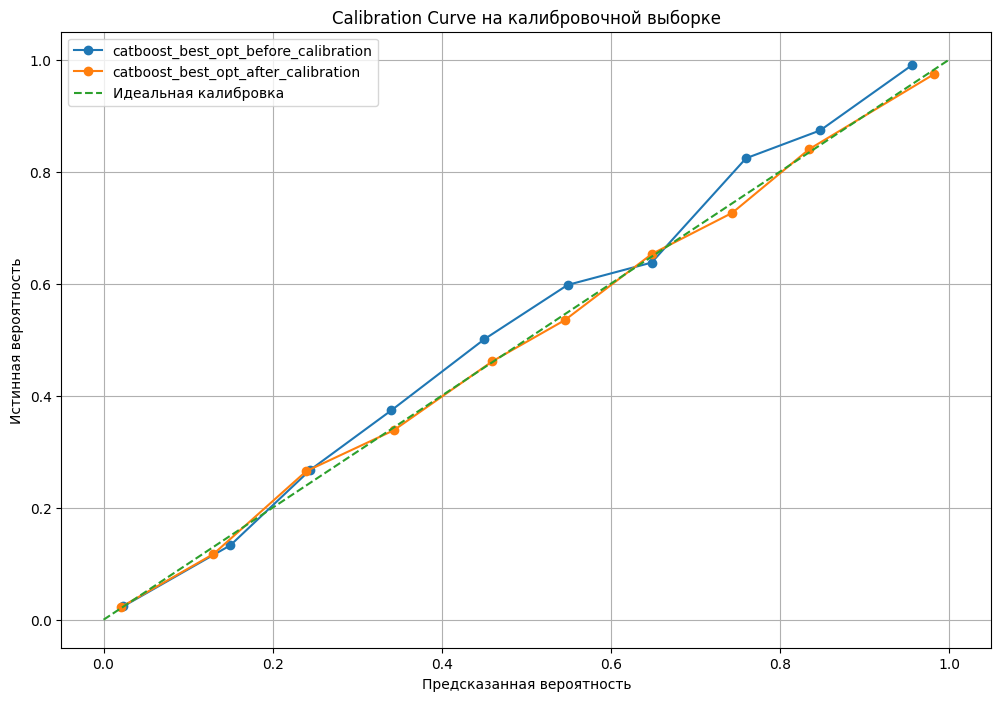

,catboost_best_opt_before_calibration,catboost_best_opt_after_calibration
accuracy,8.134215e-01,8.056262e-01
precision_binary,6.540670e-01,6.371560e-01
recall_binary,7.833811e-01,7.959885e-01
f1_binary,7.129074e-01,7.077707e-01
inc_metric,2.535015e+08,2.510485e+08


Brier score:  
до калибровки: 0.1150 
после 0.1147.


In [123]:
plot_calibration_curve(
    y_calib,
    list(calibration_probabilities.values()),
    list(calibration_probabilities.keys()),
    title='Calibration Curve на калибровочной выборке',
)

y_calib_pred_best_model = (y_calib_proba_best_model >= best_model_threshold).astype(int)
y_calib_pred_best_model_calibrated = (
    y_calib_proba_best_model_calibrated >= best_model_threshold
).astype(int)

calibration_business_results_df = get_result_df(
    model_names=[
        f'{best_model_name}_before_calibration',
        f'{best_model_name}_after_calibration',
    ],
    metric_dicts=[
        evaluate_model(y_calib, y_calib_pred_best_model),
        evaluate_model(y_calib, y_calib_pred_best_model_calibrated),
    ],
)
display(calibration_business_results_df)

brier_before = brier_score_loss(y_calib, y_calib_proba_best_model)
brier_after = brier_score_loss(y_calib, y_calib_proba_best_model_calibrated)

if brier_after < brier_before:
    print(
        f'Brier score:  \n'
        f'до калибровки: {brier_before:.4f} \n'
        f'после {brier_after:.4f}.'
    )


Анализ:
- модель еще до калибровки показывает хорошее качество по Brier Score. 
То есть после обучения она уже хорошо откалибрована. 
Объясняется это тем, что logloss выступает в качестве функции потерь и метрикой итоговой оценки модели для отбора лучшей при обучении. Logloss автоматически калибрует модель.
- этап калибровки практически не изменил Brier score

### Поиск порога классификации

In [124]:
y_calib_proba_best_model_calibrated = best_model_calibrated.predict_proba(X_calib_best_model)[:, 1]

threshold_candidates = np.unique(
    np.r_[
        np.linspace(0.01, 0.99, 99),
    ]
)

threshold_results = []
for threshold in threshold_candidates:
    y_calib_pred_threshold = (
        y_calib_proba_best_model_calibrated >= threshold
    ).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'inc_metric': inc_rev_metric(y_calib, y_calib_pred_threshold),
        'predicted_cancel_share': y_calib_pred_threshold.mean(),
    })

threshold_results_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_results_df.loc[
    threshold_results_df['inc_metric'].idxmax()
]

best_model_calibrated_threshold = best_threshold_row['threshold']
best_model_calibrated_calib_pred = (
    y_calib_proba_best_model_calibrated >= best_model_calibrated_threshold
).astype(int)
best_model_calibrated_threshold_metrics = evaluate_model(
    y_calib,
    best_model_calibrated_calib_pred,
)

display(
    threshold_results_df
    .sort_values('inc_metric', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
best_model_calibrated_threshold_metrics

,threshold,inc_metric,predicted_cancel_share
0,0.43,255522000,0.305203
1,0.44,255336500,0.304355
2,0.42,254211000,0.324182
3,0.46,254115500,0.278936
4,0.45,254082000,0.279444
5,0.41,254034500,0.325030
6,0.40,253934000,0.326555
7,0.38,253445000,0.336723
8,0.39,253360000,0.334350
9,0.47,253313000,0.270971


{'accuracy': 0.8274868666327742,
 'precision_binary': 0.7018323153803443,
 'recall_binary': 0.7243553008595989,
 'f1_binary': 0.7129159616469262,
 'inc_metric': np.int64(255522000)}

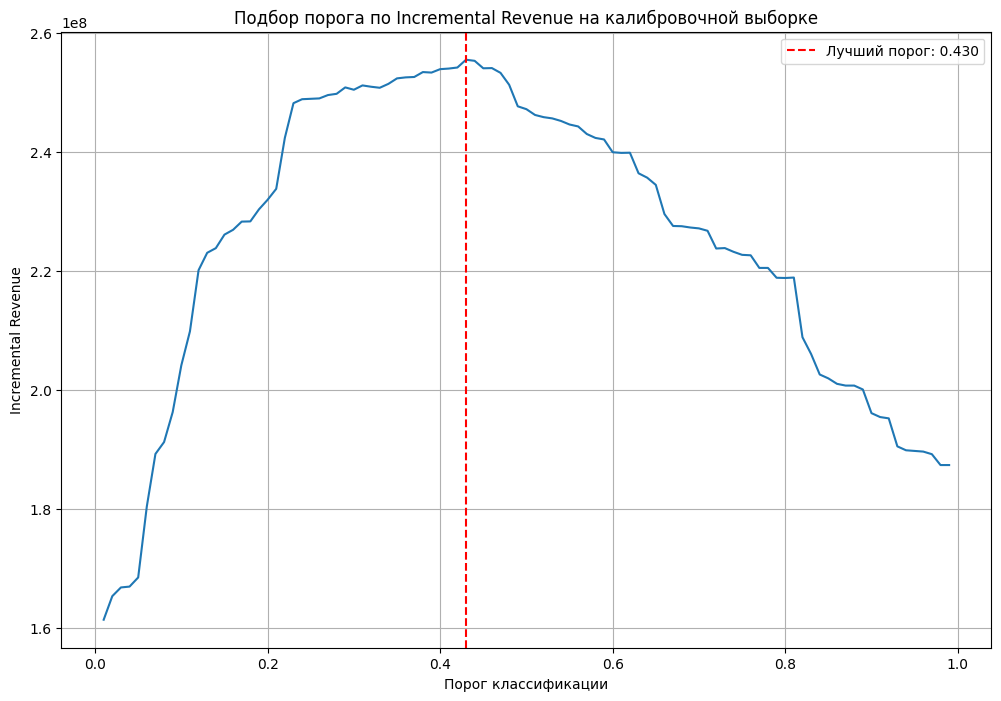

In [126]:
plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['inc_metric'],
)
plt.axvline(
    best_model_calibrated_threshold,
    color='red',
    linestyle='--',
    label=f'Лучший порог: {best_model_calibrated_threshold:.3f}',
)
plt.xlabel('Порог классификации')
plt.ylabel('Incremental Revenue')
plt.title('Подбор порога по Incremental Revenue на калибровочной выборке')
plt.legend()
plt.grid()
plt.show()

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [127]:
old_threshold_calib_pred = (
    y_calib_proba_best_model_calibrated >= best_model_threshold
).astype(int)

old_threshold_ir = inc_rev_metric(y_calib, old_threshold_calib_pred)
new_threshold_ir = best_model_calibrated_threshold_metrics['inc_metric']
threshold_ir_delta = new_threshold_ir - old_threshold_ir

threshold_comparison_df = pd.DataFrame([
    {
        'threshold_type': 'previous_business_threshold',
        'threshold': best_model_threshold,
        'inc_metric': old_threshold_ir,
        'predicted_cancel_share': old_threshold_calib_pred.mean(),
    },
    {
        'threshold_type': 'calibrated_best_threshold',
        'threshold': best_model_calibrated_threshold,
        'inc_metric': new_threshold_ir,
        'predicted_cancel_share': best_model_calibrated_calib_pred.mean(),
    },
])

display(threshold_comparison_df)

,threshold_type,threshold,inc_metric,predicted_cancel_share
0,previous_business_threshold,0.325704,251048500,0.369429
1,calibrated_best_threshold,0.430000,255522000,0.305203


In [ ]:
# изменение по ключевой метрике после подбора порога (%):
threshold_comparison_df['inc_metric'].diff() / threshold_comparison_df['inc_metric'].max() * 100

0        NaN
1    1.75073
Name: inc_metric, dtype: float64

Итог:
- подбор порога практически улучшил inc_metric на 1.75%
- новый порог можно рекомендовать к использованию при предсказании отмены брони

### Анализ матрицы классификаций

#### Подготовка предсказаний

In [131]:
y_calib_proba_final = best_model_calibrated.predict_proba(X_calib_best_model)[:, 1]
y_test_proba_final = best_model_calibrated.predict_proba(X_test_best_model)[:, 1]

y_calib_pred_final = (y_calib_proba_final >= best_model_calibrated_threshold).astype(int)
y_test_pred_final = (y_test_proba_final >= best_model_calibrated_threshold).astype(int)

final_threshold = best_model_calibrated_threshold
final_threshold

np.float64(0.43)

#### Матрицы ошибок

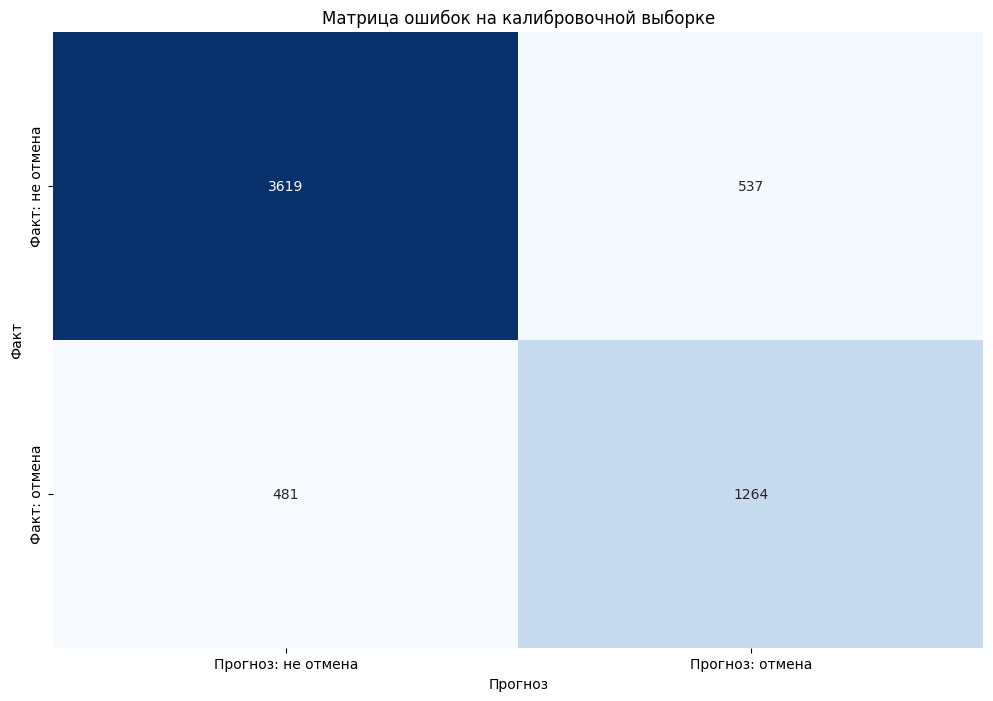

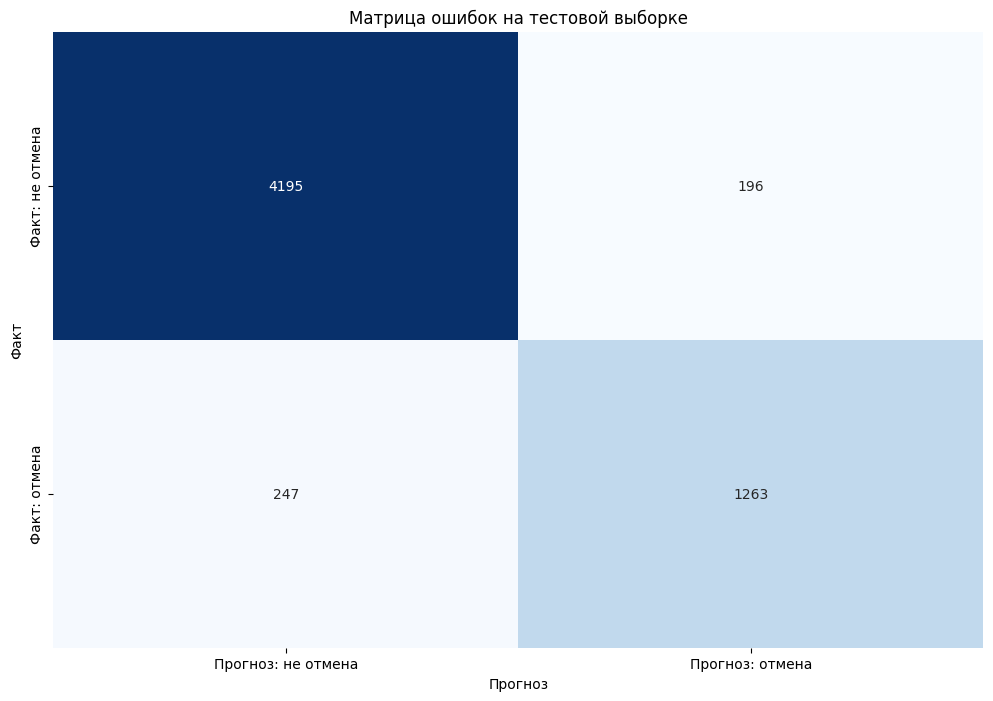

In [132]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm,
        index=['Факт: не отмена', 'Факт: отмена'],
        columns=['Прогноз: не отмена', 'Прогноз: отмена'],
    )

    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.ylabel('Факт')
    plt.xlabel('Прогноз')
    plt.show()


plot_confusion_matrix(
    y_calib,
    y_calib_pred_final,
    'Матрица ошибок на калибровочной выборке',
)

plot_confusion_matrix(
    y_test,
    y_test_pred_final,
    'Матрица ошибок на тестовой выборке',
)

Анализ: 
- матрица ошибок имеет схожий вид на калибрововчной и тестовой выборках, что свидетельствует о стабильности модели
- матрица ошибок имеет преимущественно диагональный вид (числа вне диагонали на порядок меньше диагональных элементов). Следовательно, модель допускает мало ошибок. Она хорошо настроена и имеет высокую предсказательную способность


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

#### IR и метрики стабильности

In [133]:
val_final_metrics = evaluate_model(y_calib, y_calib_pred_final)
test_final_metrics = evaluate_model(y_test, y_test_pred_final)

stability_results_df = get_result_df(
    model_names=['calibration', 'test'],
    metric_dicts=[val_final_metrics, test_final_metrics],
).T

stability_results_df['inc_metric_per_booking'] = [
    val_final_metrics['inc_metric'] / len(y_calib),
    test_final_metrics['inc_metric'] / len(y_test),
]
stability_results_df['predicted_cancel_share'] = [
    y_calib_pred_final.mean(),
    y_test_pred_final.mean(),
]
stability_results_df['true_cancel_share'] = [
    y_calib.mean(),
    y_test.mean(),
]

display(stability_results_df)

confusion_summary_df = pd.DataFrame(
    [
        dict(
            dataset='calibration',
            **dict(zip(['tn', 'fp', 'fn', 'tp'], confusion_matrix(y_calib, y_calib_pred_final, labels=[0, 1]).ravel())),
        ),
        dict(
            dataset='test',
            **dict(zip(['tn', 'fp', 'fn', 'tp'], confusion_matrix(y_test, y_test_pred_final, labels=[0, 1]).ravel())),
        ),
    ]
)
display(confusion_summary_df)

,accuracy,precision_binary,recall_binary,f1_binary,inc_metric,inc_metric_per_booking,predicted_cancel_share,true_cancel_share
calibration,0.827487,0.701832,0.724355,0.712916,255522000.0,43301.474326,0.305203,0.295713
test,0.924928,0.865661,0.836424,0.850792,310109000.0,52551.940349,0.247246,0.255889


,dataset,tn,fp,fn,tp
0,calibration,3619,537,481,1264
1,test,4195,196,247,1263


In [144]:
stability_results_df['f1_binary'].diff() / stability_results_df['f1_binary'].max() * 100

calibration          NaN
test           16.205563
Name: f1_binary, dtype: float64

#### Вывод о стабильности

In [134]:
val_ir_per_booking = stability_results_df.loc['calibration', 'inc_metric_per_booking']
test_ir_per_booking = stability_results_df.loc['test', 'inc_metric_per_booking']
ir_per_booking_delta = test_ir_per_booking - val_ir_per_booking

val_f1 = stability_results_df.loc['calibration', 'f1_binary']
test_f1 = stability_results_df.loc['test', 'f1_binary']
f1_delta = test_f1 - val_f1

val_pred_cancel_share = stability_results_df.loc['calibration', 'predicted_cancel_share']
test_pred_cancel_share = stability_results_df.loc['test', 'predicted_cancel_share']
pred_cancel_share_delta = test_pred_cancel_share - val_pred_cancel_share

print(f'Используемый порог классификации: {final_threshold:.4f}.')
print(
    f"IR на калибровочной выборке: {val_final_metrics['inc_metric']:,.0f}; "
    f"на тестовой выборке: {test_final_metrics['inc_metric']:,.0f}."
)
print(
    f'IR на одно бронирование изменился на {ir_per_booking_delta:,.2f}; '
    f'F1 binary изменился на {f1_delta:.4f}.'
)


print(f'Разница по F1 binary на calibration и test: {f1_delta}')

Используемый порог классификации: 0.4300.
IR на калибровочной выборке: 255,522,000; на тестовой выборке: 310,109,000.
IR на одно бронирование изменился на 9,250.47; F1 binary изменился на 0.1379.
Разница по F1 binary на calibration и test: 0.13787555064677537



Итог:
- Ключевая финансовая метрика показала существенный рост на тестовых данных, что говорит об отсутсвии переобучения и высокой обобщающей способности
- главная финансовая метрика на test выросла на 20% - модель действительно эффективна на новых данных
- Качество классификации по F1 binary существенно выросло на test-е (+16.2%) и достигло 0.85. Это говорит о высокой точности предсказаний редкого класса

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


In [135]:
# лучшая модель
best_model_calibrated

CalibratedClassifierCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=2000),
                       estimator=CatBoostClassifier(cat_features=('sales_channel', 'meal_plan', 'room_type'), eval_metric='Logloss', l2_leaf_reg=4.929304190194767, learning_rate=0.10564175841868291, loss_function='Logloss', max_depth=5, n_estimators=111, random_state=42, verbose=False),
                       method='isotonic', n_jobs=-1)

In [136]:
# лучший порог приянтия решений
final_threshold

np.float64(0.43)

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### Анализ важности признаков

In [137]:
def show_shap_analysis(model, name, X_data):
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_data)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_data, plot_type="dot", show=False)
    axes[0].set_title(
        f"Распределение влияния признаков для {name}", fontsize=14, pad=15
    )

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_data, plot_type="bar", show=False)
    axes[1].set_title(
        f"Глобальная важность (средний |SHAP|) для {name}",
        fontsize=14,
        pad=15,
    )

    plt.tight_layout()
    plt.show()


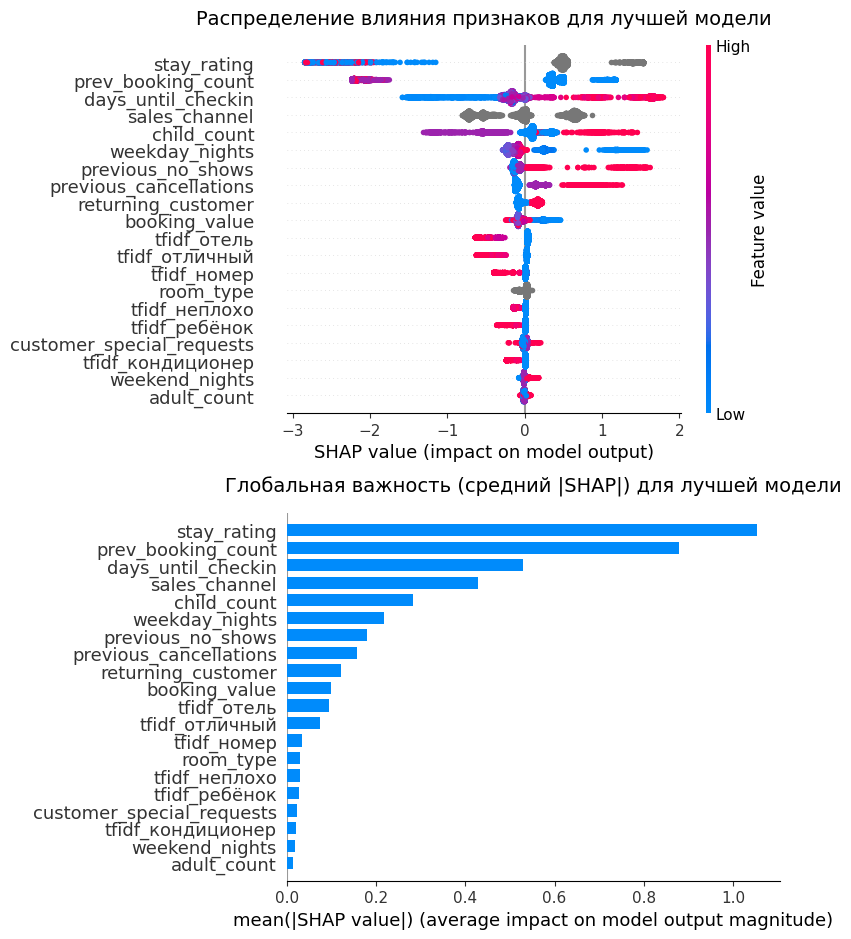

In [138]:
show_shap_analysis(best_model_full, 'лучшей модели', X_calib_best_model)

Анализ:

Наиболее важный признак по оценке модели: оценка клиента о прошлом посещении и количество предыдущих бронирований. Эти признаки отражают лояльность клиента к сети отелей. Тут прослеживается отрицательная связь с таргетом: чем более лояльный клиент, тем меньше вероятно он отменит бронь.
Высокая важность у признака: кол-во дней до заезда. Это объясняется тем, что при длительном сроке до заезда высокая вероятность, что планы изменятся и придется отменять бронь.

Канал продаж входит в топ по важности: можно предположить, что через какие-то каналы клиентам проще ставить и отменять бронь. Стоит провести дополнительное исследование способов оформления.

Менее всего влияют на отмену брони: кол-во проживающих взрослых, информация из отзывов, особые запросы клиентов во время предыдущих посещений.

<span style="color: blue; font-weight:">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## Этап 3: расчёт экономической эффективности модели

### Подготовка данных для расчета экономики


In [145]:
TARGET_CANCEL_SHARE = 0.10
MAX_OCCUPANCY_DECREASE = 8
TARGET_RELATIVE_IR = 50

y_pred = y_test_pred_final.copy()
y_pred_before = np.zeros_like(np.asarray(y_test), dtype=int)


def get_confusion_counts(y_true, y_pred):
    """Матрица ошибок в виде словаря"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}


def safe_relative_change(after, before):
    """Относительое изменение"""
    return (after - before) / before * 100

### Расчет показателей до и после внедрения модели


In [146]:
test_counts = get_confusion_counts(y_test, y_pred)

total_bookings = len(y_test)
total_cancellations = int(np.asarray(y_test).sum())
total_success = total_bookings - total_cancellations

ir_before = inc_rev_metric(y_test, y_pred_before)
ir_after = inc_rev_metric(y_test, y_pred)
incremental_revenue = ir_after - ir_before

cancel_share_before = total_cancellations / total_bookings
cancel_share_after = test_counts['fn'] / total_bookings

occupancy_before = total_success / total_bookings
occupancy_after = (total_success + test_counts['tp']) / total_bookings

business_metrics_df = pd.DataFrame(
    [
        {
            'period': 'до внедрения',
            'cancel_share': cancel_share_before * 100,
            'occupancy': occupancy_before * 100,
            'IR': ir_before,
        },
        {
            'period': 'после внедрения',
            'cancel_share': cancel_share_after * 100,
            'occupancy': occupancy_after * 100,
            'IR': ir_after,
        },
    ]
)

business_metrics_df[['cancel_share', 'occupancy']] = business_metrics_df[
    ['cancel_share', 'occupancy']
].round(2)
business_metrics_df['IR'] = business_metrics_df['IR'].round(0).astype('int64')

display(business_metrics_df)
display(pd.DataFrame([test_counts]))

,period,cancel_share,occupancy,IR
0,до внедрения,25.59,74.41,185824500
1,после внедрения,4.19,95.81,310109000


,tn,fp,fn,tp
0,4195,196,247,1263


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>
`occupancy_after = (total_success + test_counts['tp']) / total_bookings` — это (tn + tp + fp) / total. Но в контексте данной брони при tp и fp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN), когда номер свободен и может быть снова забронирован — это не заселённый номер.
</font>

</span><br><span style="color: purple; font-weight: bold"> Исправил </span>

### Динамика показателей и достижение целевых уровней

In [147]:
cancel_share_dynamic = (cancel_share_before - cancel_share_after) / cancel_share_before * 100
occupancy_dynamic = (occupancy_before - occupancy_after) / occupancy_before * 100
relative_ir = safe_relative_change(ir_after, ir_before)

business_targets_df = pd.DataFrame(
    [
        {
            'metric': 'Доля отмен после внедрения',
            'value': cancel_share_after * 100,
            'target': '<= 10%',
            'target_reached': cancel_share_after <= TARGET_CANCEL_SHARE,
        },
        {
            'metric': 'Снижение загрузки',
            'value': occupancy_dynamic,
            'target': '<= 8%',
            'target_reached': occupancy_dynamic <= MAX_OCCUPANCY_DECREASE,
        },
        {
            'metric': 'Относительный IR',
            'value': relative_ir,
            'target': '>= 50%',
            'target_reached': relative_ir >= TARGET_RELATIVE_IR,
        },
    ]
)

business_targets_df['value'] = business_targets_df['value'].round(2)
business_targets_df['target_reached'] = business_targets_df['target_reached'].map({True: 'да', False: 'нет'})

display(business_targets_df)

print(f'Динамика доли отмен: {cancel_share_dynamic:.2f}%.')
print(f'Динамика загрузки: {occupancy_dynamic:.2f}%.')
print(f'Прирост IR: {incremental_revenue:,.0f}.')
print(f'Относительный IR: {relative_ir:.2f}%.')

,metric,value,target,target_reached
0,Доля отмен после внедрения,4.19,<= 10%,да
1,Снижение загрузки,-28.76,<= 8%,да
2,Относительный IR,66.88,>= 50%,да


Динамика доли отмен: 83.64%.
Динамика загрузки: -28.76%.
Прирост IR: 124,284,500.
Относительный IR: 66.88%.


### Выводы по экономической эффективности

In [148]:
cancel_target_reached = cancel_share_after <= TARGET_CANCEL_SHARE
occupancy_target_reached = occupancy_dynamic <= MAX_OCCUPANCY_DECREASE
relative_ir_target_reached = relative_ir >= TARGET_RELATIVE_IR
all_targets_reached = all([
    cancel_target_reached,
    occupancy_target_reached,
    relative_ir_target_reached,
])

print(
    'После внедрения модели доля необработанных отмен составляет '
    f'{cancel_share_after:.2%} против {cancel_share_before:.2%} до внедрения.'
)
print(
    'Загрузка изменилась с '
    f'{occupancy_before:.2%} до {occupancy_after:.2%}; '
    f'динамика по заданной формуле: {occupancy_dynamic:.2f}%.'
)
print(
    f'Финансовый результат до внедрения: {ir_before:,.0f}; '
    f'после внедрения: {ir_after:,.0f}; прирост: {incremental_revenue:,.0f}.'
)

if all_targets_reached:
    print('Все целевые бизнес-показатели достигнуты: модель можно рекомендовать к внедрению.')
else:
    print('Не все целевые бизнес-показатели достигнуты: перед внедрением нужно проверить стоимость ложных срабатываний и допустимый уровень овербукинга.')

После внедрения модели доля необработанных отмен составляет 4.19% против 25.59% до внедрения.
Загрузка изменилась с 74.41% до 95.81%; динамика по заданной формуле: -28.76%.
Финансовый результат до внедрения: 185,824,500; после внедрения: 310,109,000; прирост: 124,284,500.
Все целевые бизнес-показатели достигнуты: модель можно рекомендовать к внедрению.


## Этап 4: выводы по проекту

### Выводы о проделанной работе



**Подготовка данных**

Исходные данные загружены из двух таблиц: датасет с инфомрацией о бронировании и отзывах.
Первичный анализ при загрузке подтвердил корректность считываемых данных и соотвествие их описанию.
Исследовательский анализ выявил малую долю дубликатов (менее 0.1%), которые были удалены. 
Также были выявленые и исправлены опечатки в названии колонок. 
На основе текстовой информации из отзывов были сформированы новые признак: наиболее значимые по метрике TF-IDF слова, характеризующие отзывы.
Сформированы признак лояльности клиентов: кол-во предыдущих посещений. Добавлен признак сезонности: месяц заселения.
Сформирован итоговый датасет: без дублей, но с пропусками в признаках лояльности с долей 63%. Это объясняется тем, что малая доля клиентов пишет отзывы и оценивают свое пребывание в отеле.

**Моделирование**

Проведено обучение 2 базовых моделей градиентного бустинга: CatBoostClassifier и XGBClassifier. 
Базовые модели показали приемлемые метрики качества предсказаний (более 0.7 f1-macro и близкие показатели по IR) и отсутствие явного переобучения (малое отличие train и valid метрик). Это говорит о том, что модели применимы к поставленной задаче. В то же время базовые модели сущесвтенно хуже предсказывают малочисленный класс отмены броней. Возникает потребность в оптимизации гиперпараметров.

Для улучшения качества предсказаний и, в конечном итоге, для увеличения финансовых показателей модели, была проведена оптимизация гиперпарметров по показателю IR. По результатам оптимизации была выявляна лучшая модель: CatBoostClassifier с подобранными гиперпараметрами. Проведена калибровка лучшей модели и определен оптимальный по финансовым показателям порог по вероятности для принятия решения: прогнозируем отмену брони или нет. 

**Оценка метрик**

Анализ матрицы ошибок позволяет понять, что разработанная модель с высокой точностью предсказывает как отмены, так и подтверждения броней.
Модель показала стабильное качество на validate и test выборках и рекомендована к внедрению, поскольку все требования по ключевым метрикам выполнены.


**Анализа важности факторов**

Анализ важности признаков показал, что рейтинг и количество предыдущих броней - наиболее важные факторы для прогноза отмены брони. Если клиент лояльный согласно истории, то вероятней всего он не отменит бронь. 
Важным вактором является время до заезда при бронировании. Чем больше промежуток времени в запасе, тем вероятней бронь отменяется. 

Наименне важные признаки - содержание отзывов, кол-во взрослых людей при заселении.



### Выводы по анализу эффективности модели

Разработанная модель позволяет принимать обоснованные решения по прогнозированию отмены броней в отеле.
Модель обучена на исторических данных о бронях клиентов и информации из отзывов.

Говоря об экономической эффективности разработанной модели:

- После внедрения модели доля необработанных отмен составляет 4.19% против 25.59% до внедрения.
- Загрузка изменилась с 74.41% до 95.81%;
Финансовый результат до внедрения: 185,824,500; после внедрения: 310,109,000; прирост: 124,284,500.

Все целевые бизнес-показатели достигнуты: модель рекомендована к внедрению.

Основными признаками, позволяющими прогнозировать отмену брони являются: рейтинг прошлого посещения отеля (высокий рейтинг - клент скорее всего не отменит бронь), информация о прошлых подтвержденных визитах (уже подтверждал - скорее всего и в этот раз подтвредит), время до заезда (чем больше времени, тем вероятней отмена).

*Рекомендации для бизнеса*:
- внедрение модели позволит существенно повысить заполняемость номеров в отеле и прибыльность компании
- информация о рейтинге и количестве предыдущих подтвержденных броней крайне важная. Стоит простимулировать клиентов давать обратную связь, чтобы потом лучше прогнозировать отмены. 
- важным фактором является канал бронирования. Необходимо провести дополнительное исследование, которое позволит понять, через какие каналы люди отменяют брони и как можно на это повлиять.
- большой срок перед заездом увеличивает вероятность отмены. Рекомендуется продумать доп. условия для такого рода случаев. Допустим, гибкость при переносе брони на другой день.   

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'> Арсений, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>